In [120]:
!pip install -q geopandas shapely pyproj rasterio folium hdbscan pulp osmnx fiona tqdm scikit-learn

In [ ]:

# === 1-Imports & constants ===
import os, math, warnings, re
import numpy as np, pandas as pd, geopandas as gpd
import fiona
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix
import folium
from folium.plugins import HeatMap, MiniMap

warnings.filterwarnings("ignore", category=UserWarning)

# ---- Paths ----
DATA_DIR = "/mnt/e/MTU/Thesis/Datasets/processed/"
POP_GPKG    = os.path.join(DATA_DIR, "population_clean.gpkg")
POP_LAYER   = "layer"  # <- your file uses a single layer named 'layer'
EXIST_GPKG  = os.path.join(DATA_DIR, "existing_towers_clean.gpkg")
EXIST_LAYER = "layer"
WATER_GPKG  = os.path.join(DATA_DIR, "water_polygons.gpkg")
WATER_SHP   = os.path.join(DATA_DIR, "water_polygons.shp")
DEM_TIF     = os.path.join(DATA_DIR, "cork_srtmgl1.tif")
ROADS_GPKG  = os.path.join(DATA_DIR, "cork_roads.gpkg")

# ---- Planning params ----
SEED = 42
np.random.seed(SEED)

# Receiver + interference assumptions for SINR calculations
NF_NR_DB = 7.0                  # receiver noise figure

MIN_POP_MUST_SERVE = 500
URBAN_BUF = None 

SECTORS_PER_SITE   = 3
EFF_OVERHEAD       = 0.85
SNR_CAP_DB         = 30.0
D_MIN_KM           = 0.001

# --- Receiver & interference assumptions (for SNR/SINR) ---
NF_LTE_DB             = 7.0     # typical LTE receiver noise figure
NF_NR_DB              = 7.0     # typical NR receiver noise figure
IO_HEADROOM_DB_URBAN  = 3.0     # dB to account for inter-cell interference etc.
IO_HEADROOM_DB_RURAL  = 1.5


# Coverage thresholds & margins
MARGIN_COV_URBAN   = 14.0
MARGIN_COV_RURAL   = 10.0
COV_RSRP_DBM_URBAN = -112.0
COV_RSRP_DBM_RURAL = -110.0

# Capacity margins
MARGIN_CAP_URBAN   = 12.0
MARGIN_CAP_RURAL   = 10.0

# Bands
BANDS_MACRO = [
    {"name":"LTE700","tech":"LTE","f_mhz":700,"bw_mhz":10,"tx_dbm":46,"hb_m":40,"rmax_km":12.0,"env_gain_db":0},
    {"name":"LTE800","tech":"LTE","f_mhz":800,"bw_mhz":10,"tx_dbm":46,"hb_m":35,"rmax_km":10.0,"env_gain_db":0},
    {"name":"LTE1800","tech":"LTE","f_mhz":1800,"bw_mhz":15,"tx_dbm":43,"hb_m":30,"rmax_km":6.0,"env_gain_db":0},
]
BANDS_NR = [
    {"name":"NR3500","tech":"NR","f_mhz":3500,"bw_mhz":100,"tx_dbm":46,"hb_m":30,"snr_db":6,"rmax_km":1.6,"env_gain_db":0}
]
SMALLCELL_PARAMS = {"tx_dbm":40, "hb_m":10, "rmax_km":0.85}

# Demand → BH
MARKET_SHARE            = 0.30
ADOPTION_RATE           = 0.80
CONCURRENCY             = 0.05
BH_TARGET_MBPS_PER_USER = 2.0


In [ ]:
# === 2-Load data (Cork schema) 
import math
from shapely.geometry import box

def smart_to_crs(gdf, crs=4326):
    if gdf is None or len(gdf)==0:
        return gpd.GeoDataFrame(geometry=[], crs=f"EPSG:{crs}")
    if getattr(gdf, "crs", None) is None:
        gdf = gdf.set_crs(crs)
    return gdf.to_crs(crs)

# 2.1 Demand (population)
if not os.path.exists(POP_GPKG):
    raise FileNotFoundError(f"Not found: {POP_GPKG}")
try:
    demand = gpd.read_file(POP_GPKG, layer=POP_LAYER)
except Exception:
    first = fiona.listlayers(POP_GPKG)[0]
    demand = gpd.read_file(POP_GPKG, layer=first)

# to ensure geometry
if ("geometry" not in demand.columns or demand.geometry.is_empty.any()) and {"X","Y"}.issubset(demand.columns):
    demand = gpd.GeoDataFrame(demand, geometry=[Point(xy) for xy in zip(demand["X"], demand["Y"])], crs=4326)
demand = smart_to_crs(demand, 4326).copy()


pop_col = None
if "pop" in demand.columns:
    pop_col = "pop"
elif "Z" in demand.columns and np.issubdtype(demand["Z"].dtype, np.number):
    pop_col = "Z"
else:
    num_cols = [c for c in demand.columns if c != "geometry" and np.issubdtype(demand[c].dtype, np.number)]
    if num_cols:
        sums = demand[num_cols].fillna(0).sum().sort_values(ascending=False)
        pop_col = str(sums.index[0])
if pop_col != "pop":
    demand = demand.rename(columns={pop_col: "pop"}) if pop_col else demand.assign(pop=1.0)
demand["pop"] = pd.to_numeric(demand["pop"], errors="coerce").fillna(0).astype(float)

print(f"[POP] Using column 'pop' (source: {'Z' if pop_col=='Z' else pop_col if pop_col else 'fallback=1.0'}).")
print(f"      Rows: {len(demand):,} | Sum(pop): {int(demand['pop'].sum()):,}")

# --- Build an AOI bbox around demand (pad in km) ---
AOI_PAD_KM = 8.0  # increase if you want a wider safety margin
minx, miny, maxx, maxy = demand.total_bounds
lat0 = float(demand.geometry.y.mean())
def km_to_deg(km, lat_deg):
    # ~1 deg lat = 111 km; 1 deg lon = 111*cos(lat) km
    dlat = km / 111.0
    dlon = km / (111.0 * max(0.1, math.cos(math.radians(lat_deg))))
    return dlon, dlat
pad_lon, pad_lat = km_to_deg(AOI_PAD_KM, lat0)
aoi_poly = box(minx - pad_lon, miny - pad_lat, maxx + pad_lon, maxy + pad_lat)

# 2.2 Water (AOI read + sjoin mask)
water = gpd.GeoDataFrame(geometry=[], crs=4326)
if os.path.exists(WATER_GPKG):
    try:
        water = gpd.read_file(WATER_GPKG, layer="water", mask=aoi_poly)
    except Exception:
        try:
            water = gpd.read_file(WATER_GPKG, mask=aoi_poly)
        except Exception:
            pass
elif os.path.exists(WATER_SHP):
    try:
        water = gpd.read_file(WATER_SHP, mask=aoi_poly)
    except Exception:
        water = gpd.read_file(WATER_SHP)

# fix CRS if missing, then to 4326
if len(water):
    if water.crs is None:
        water = water.set_crs(4326)
    water = smart_to_crs(water, 4326)
    # Fast mask: spatial join points-within-polygons (no expensive union)
    wkeep = gpd.sjoin(demand[["geometry"]], water[["geometry"]], predicate="within", how="left")["index_right"].isna()
    before = len(demand)
    demand = demand.loc[wkeep].reset_index(drop=True)
    print(f"[WATER] AOI polygons: {len(water):,} | Masked {before - len(demand):,} demand cells over water.")
else:
    print("[WATER] No water features loaded within AOI.")

# 2.3 Existing towers (filter to AOI for speed)
existing = gpd.GeoDataFrame(geometry=[], crs=4326)
if os.path.exists(EXIST_GPKG):
    try:
        existing = gpd.read_file(EXIST_GPKG, layer=EXIST_LAYER)
    except Exception:
        try:
            first = fiona.listlayers(EXIST_GPKG)[0]
            existing = gpd.read_file(EXIST_GPKG, layer=first)
        except Exception:
            pass
if len(existing):
    existing = smart_to_crs(existing, 4326)
    existing = existing.loc[existing.intersects(aoi_poly)].reset_index(drop=True)

# 2.4 Roads 
roads = None
if os.path.exists(ROADS_GPKG):
    try:
        roads = gpd.read_file(ROADS_GPKG, layer="edges", mask=aoi_poly)
        roads = smart_to_crs(roads, 4326)
    except Exception:
        try:
            roads = smart_to_crs(gpd.read_file(ROADS_GPKG), 4326)
            roads = roads.loc[roads.intersects(aoi_poly)].reset_index(drop=True)
        except Exception:
            roads = None

print(f"[Layers] AOI bounds: ({aoi_poly.bounds[0]:.4f}, {aoi_poly.bounds[1]:.4f})–({aoi_poly.bounds[2]:.4f}, {aoi_poly.bounds[3]:.4f})")
print(f"[Layers] Water (AOI): {len(water)} | Existing towers (AOI): {len(existing)} | Roads (AOI): {0 if roads is None else len(roads)}")


[POP] Using column 'pop' (source: Z).
      Rows: 25,629 | Sum(pop): 1,451,896
[WATER] AOI polygons: 14 | Masked 992 demand cells over water.
[Layers] AOI bounds: (-10.1142, 51.3483)–(-7.3883, 52.4675)
[Layers] Water (AOI): 14 | Existing towers (AOI): 333 | Roads (AOI): 82163


In [123]:

# === 3-Must-Serve (≥500 pop per demand cell) ===
demand["must_serve"] = demand["pop"].astype(float) >= MIN_POP_MUST_SERVE
print(f"[MS] must_serve hexes: {int(demand['must_serve'].sum())}/{len(demand)} ({demand['must_serve'].mean():.1%})")


[MS] must_serve hexes: 458/24637 (1.9%)


In [ ]:

# === 4-RF Helpers ===
def haversine_km(lon1, lat1, lon2, lat2):
    lon1 = np.asarray(lon1, float); lat1 = np.asarray(lat1, float)
    R = 6371.0088
    dlon = np.radians(lon2 - lon1); dlat = np.radians(lat2 - lat1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def thermal_noise_dbm(bw_mhz):
    return -174 + 10*np.log10(bw_mhz*1e6)

def noise_dbm_for_band(bw_mhz, nf_db=5.0):
    return thermal_noise_dbm(bw_mhz) + nf_db

def snr_db_link(rx_dbm, bw_mhz, nf_db, io_headroom_db=0.0):
    return rx_dbm - (thermal_noise_dbm(bw_mhz) + nf_db + io_headroom_db)


def sinr_noise_dbm(bw_mhz, nf_db=5.0, ioc_db=0.0):
    return thermal_noise_dbm(bw_mhz) + nf_db + ioc_db


def path_loss(d_km, band, hb_m):
    d_km = np.asarray(d_km, float)
    f = band.get("f_mhz", 800.0)
    hm = 1.5
    a_hm = (1.1*np.log10(f) - 0.7)*hm - (1.56*np.log10(f) - 0.8)
    L = 46.3 + 33.9*np.log10(f) - 13.82*np.log10(hb_m) - a_hm + (44.9 - 6.55*np.log10(hb_m))*np.log10(np.maximum(d_km, 0.001))
    return L + 3.0  # clutter margin

def coverage_matrix_macro_rsrp(demand_gdf, site_gdf, bands):
    nD, nC = len(demand_gdf), len(site_gdf)
    if nC == 0: return csr_matrix((nD, 0), dtype=np.uint8)
    Dl, Dt = demand_gdf.geometry.x.values, demand_gdf.geometry.y.values
    rows, cols = [], []
    for j in range(nC):
        Cl, Ct = site_gdf.geometry.iloc[j].x, site_gdf.geometry.iloc[j].y
        d = np.maximum(haversine_km(Dl, Dt, Cl, Ct), D_MIN_KM)
        urban = (URBAN_BUF is not None and site_gdf.geometry.iloc[j].within(URBAN_BUF))
        margin = MARGIN_COV_URBAN if urban else MARGIN_COV_RURAL
        thr = COV_RSRP_DBM_URBAN if urban else COV_RSRP_DBM_RURAL
        ok_any = np.zeros(nD, bool)
        for b in bands:
            rmax = b.get("rmax_km", None)
            mask = (d <= rmax) if rmax else np.ones(nD, bool)
            pl = path_loss(d, b, b["hb_m"]) - b.get("env_gain_db",0.0)
            rx = b["tx_dbm"] - pl - margin
            ok_any |= (mask & (rx >= thr))
        idx = np.where(ok_any)[0]
        if idx.size:
            rows.extend(idx.tolist()); cols.extend([j]*idx.size)
    return csr_matrix((np.ones(len(rows), np.uint8), (rows, cols)), shape=(nD, nC)).tocsr()


In [ ]:

#Demand hotspot clustering to seed macro candidates (HDBSCAN/DBSCAN) ===
import numpy as np, pandas as pd, geopandas as gpd
from scipy.spatial.distance import cdist

def _to_3857(gdf): return gpd.GeoDataFrame(gdf).to_crs(3857) if gdf.crs is not None else gpd.GeoDataFrame(gdf).set_crs(4326).to_crs(3857)

HOT_FRACTION = 0.30  # top 30% by pop
hot = demand.sort_values("pop", ascending=False).head(max(50, int(HOT_FRACTION*len(demand)))).reset_index(drop=True)

hot_3857 = _to_3857(hot)
X = np.c_[hot_3857.geometry.x.values, hot_3857.geometry.y.values]
w = hot["pop"].to_numpy(float)

labels = None
try:
    import hdbscan
    clusterer = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=10, cluster_selection_epsilon=150.0, metric="euclidean")
    labels = clusterer.fit(X).labels_
except Exception:
    from sklearn.cluster import DBSCAN
    EPS_M, MIN_SAMPLES = 350.0, 12
    labels = DBSCAN(eps=EPS_M, min_samples=MIN_SAMPLES, metric="euclidean").fit(X).labels_

seeds = []
for lab in np.unique(labels):
    if lab < 0:  # noise
        continue
    idx = np.where(labels == lab)[0]
    if idx.size == 0:
        continue
    Xi = X[idx]; wi = w[idx]
    from scipy.spatial.distance import cdist as _cd
    D = _cd(Xi, Xi)
    med = idx[np.argmin((D * wi[None, :]).sum(axis=1))]
    seeds.append(hot.iloc[med].geometry)

seed_gdf = gpd.GeoDataFrame(geometry=seeds, crs=hot.crs).to_crs(4326)
seed_gdf["source"] = "cluster_seed"
if 'existing' not in globals():
    existing = gpd.GeoDataFrame(geometry=[], crs=4326)

cands = pd.concat([existing[["geometry"]], seed_gdf[["geometry"]]], ignore_index=True)          .drop_duplicates(subset="geometry").reset_index(drop=True)
cands = gpd.GeoDataFrame(cands, geometry="geometry", crs=4326)
print(f"[4B] hotspot clusters → seeds: {len(seed_gdf)} | candidates for 10R: {len(cands)}")


/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[4B] hotspot clusters → seeds: 3 | candidates for 10R: 309


In [ ]:
#Elevation-aware macro candidate ranking
import numpy as np, pandas as pd, geopandas as gpd, math
from sklearn.neighbors import BallTree

def _sigmoid(x): return 1.0/(1.0+np.exp(-x))

# ---- 1) Population proximity (3 km) using fast haversine BallTree
R_EARTH_KM = 6371.0088
pop_vals = demand["pop"].to_numpy(float)
pts_dem = np.radians(np.c_[demand.geometry.y.values, demand.geometry.x.values])
tree = BallTree(pts_dem, metric="haversine")

near_km = 3.0
indices = []
near_pop = np.zeros(len(cands), float)
query_pts = np.radians(np.c_[cands.geometry.y.values, cands.geometry.x.values])
rad = near_km / R_EARTH_KM
nbrs = tree.query_radius(query_pts, r=rad)
for i, idx in enumerate(nbrs):
    if idx.size:
        near_pop[i] = float(pop_vals[idx].sum())
cands["near_pop_3km"] = near_pop

# ---- 2) Terrain features from DEM: elevation, local relief (~300 m), slope
cands["elev_m"] = np.nan
cands["relief_m"] = np.nan
cands["slope_deg"] = np.nan

try:
    import rasterio
    with rasterio.open(DEM_TIF) as src:
        # SRTM ~30 m ➜ 11x11 ≈ ~330 m window
        WIN = 11
        for i, g in enumerate(cands.geometry.values):
            r, c = src.index(float(g.x), float(g.y))
            r0 = max(0, r - WIN//2); r1 = min(src.height, r + WIN//2 + 1)
            c0 = max(0, c - WIN//2); c1 = min(src.width,  c + WIN//2 + 1)
            arr = src.read(1, window=((r0, r1), (c0, c1)))
            if arr.size == 0: continue
            zc = float(arr[arr.shape[0]//2, arr.shape[1]//2])
            zmed = float(np.nanmedian(arr))
            # slope from simple central differences
            gy, gx = np.gradient(arr.astype("float32"))
            slope = np.degrees(np.arctan(np.hypot(gy, gx)))
            cands.at[i, "elev_m"]   = zc
            cands.at[i, "relief_m"] = zc - zmed
            cands.at[i, "slope_deg"]= float(np.nanmedian(slope))
except Exception as e:
    print("[4B-ELEV] DEM sampling skipped:", e)

# ---- 3) Composite terrain score
relief = np.nan_to_num(cands["relief_m"].to_numpy(float), nan=0.0)
_elev_arr = cands["elev_m"].to_numpy(float)
_elev_med = np.nanmedian(_elev_arr) if np.isfinite(_elev_arr).any() else 100.0
elev   = np.nan_to_num(_elev_arr, nan=_elev_med)
slope  = np.nan_to_num(cands["slope_deg"].to_numpy(float),nan=8.0)

relief_score = _sigmoid((relief-10.0)/20.0)              # ~0 at flat/valley, ↑ to 1 for +50–60 m relief
elev_cap     = 1.0 - _sigmoid((elev-250.0)/80.0)         # start penalizing > ~250 m
slope_pen    = 1.0 - _sigmoid((slope-12.0)/4.0) * 0.35   # small penalty for very steep ground

terrain_score = np.clip(relief_score * elev_cap * slope_pen, 0.0, 1.0)

# ---- 4) Re-rank candidates (population × terrain)
W_TERRAIN = 0.35
score = cands["near_pop_3km"].to_numpy(float) * (1.0 - W_TERRAIN + W_TERRAIN*terrain_score)
cands["elev_rank_score"] = score

# ---- 5) Thin out by min separation while keeping the highest scores
MIN_SEP_KM = 1.2  # macro min spacing; tweak 0.8–1.5 depending on density
order = np.argsort(-score)
keep_idx = []
if len(order):
    pts = np.c_[cands.geometry.x.values, cands.geometry.y.values]
    for k in order:
        p = pts[k]
        if not keep_idx:
            keep_idx.append(k); continue
        # great-circle distance to kept
        dsep = np.array([ 
            haversine_km(p[0], p[1], pts[j][0], pts[j][1]) 
            for j in keep_idx
        ])
        if (dsep >= MIN_SEP_KM).all():
            keep_idx.append(k)

cands = cands.iloc[keep_idx].reset_index(drop=True)

print(f"[4B-ELEV] Elevation-aware candidates kept: {len(cands)} "
      f"(median relief={np.nanmedian(cands['relief_m']):.1f} m, "
      f"median slope={np.nanmedian(cands['slope_deg']):.1f}°)")


[4B-ELEV] Elevation-aware candidates kept: 131 (median relief=0.0 m, median slope=54.7°)


In [ ]:

# === 5-Macro Coverage (RSRP) ===
if 'cands' not in globals() or cands is None or len(cands)==0:
    cands = existing[["geometry"]].copy() if len(existing) else gpd.GeoDataFrame(geometry=[], crs=4326)

def _rsrp_A(demand_gdf, cand_gdf, bands, margin_u, margin_r, thr_u, thr_r, rmax_scale=1.0):
    nD, nC = len(demand_gdf), len(cand_gdf)
    if nC == 0: return csr_matrix((nD, 0), dtype=np.uint8)
    Dl, Dt = demand_gdf.geometry.x.values, demand_gdf.geometry.y.values
    rows, cols = [], []
    site_is_urban = np.array([(URBAN_BUF is not None and cand_gdf.geometry.iloc[j].within(URBAN_BUF)) for j in range(nC)])
    site_margin = np.where(site_is_urban, margin_u, margin_r)
    site_thr    = np.where(site_is_urban, thr_u,    thr_r)
    for j in range(nC):
        Cl, Ct = cand_gdf.geometry.iloc[j].x, cand_gdf.geometry.iloc[j].y
        d = np.maximum(haversine_km(Dl, Dt, Cl, Ct), D_MIN_KM)
        ok_any = np.zeros(nD, bool)
        for b in bands:
            rmax = b.get("rmax_km", None)
            mask_r = (d <= rmax * rmax_scale) if rmax is not None else np.ones(nD, bool)
            pl  = path_loss(d, b, b["hb_m"]) - b.get("env_gain_db", 0.0)
            rx  = b["tx_dbm"] - pl - site_margin[j]
            ok_any |= (mask_r & (rx >= site_thr[j]))
        idx = np.where(ok_any)[0]
        if idx.size:
            rows.extend(idx.tolist()); cols.extend([j]*idx.size)
    return csr_matrix((np.ones(len(rows), np.uint8), (rows, cols)), shape=(nD, nC)).tocsr()

def ensure_macro_coverage(demand_gdf, cand_gdf, bands):
    must = demand_gdf["must_serve"].to_numpy(bool)
    A1 = _rsrp_A(demand_gdf, cand_gdf, bands, MARGIN_COV_URBAN, MARGIN_COV_RURAL, COV_RSRP_DBM_URBAN, COV_RSRP_DBM_RURAL, 1.0)
    coverable1 = (A1[must].getnnz(axis=1) > 0) if A1.shape[1]>0 else np.zeros(must.sum(), bool)
    print(f"[Coverage/Diag] Stage1 coverable must-serve: {int(coverable1.sum())}/{int(must.sum())}")
    if coverable1.all():
        return A1, cand_gdf, "strict"
    A2 = _rsrp_A(demand_gdf, cand_gdf, bands, MARGIN_COV_URBAN, MARGIN_COV_RURAL, COV_RSRP_DBM_URBAN-3, COV_RSRP_DBM_RURAL-3, 1.25)
    coverable2 = (A2[must].getnnz(axis=1) > 0) if A2.shape[1]>0 else np.zeros(must.sum(), bool)
    print(f"[Coverage/Diag] Stage2 (−3 dB thr, +25% rmax) coverable: {int(coverable2.sum())}/{int(must.sum())}")
    if coverable2.all():
        return A2, cand_gdf, "relaxed"
    # Synthesize at uncovered must-serve locations
    miss_mask = ~coverable2
    add_idx_global = np.where(must)[0][np.where(miss_mask)[0]]
    synth = demand_gdf.iloc[add_idx_global][["geometry"]].copy()
    synth["source"] = "synth_macro"
    cand2 = pd.concat([cand_gdf, synth], ignore_index=True).drop_duplicates(subset="geometry").reset_index(drop=True)
    A3 = _rsrp_A(demand_gdf, cand2, bands, max(MARGIN_COV_URBAN-4,8), max(MARGIN_COV_RURAL-4,6), COV_RSRP_DBM_URBAN-5, COV_RSRP_DBM_RURAL-5, 1.5)
    coverable3 = (A3[must].getnnz(axis=1) > 0) if A3.shape[1]>0 else np.zeros(must.sum(), bool)
    print(f"[Coverage/Diag] Stage3 (synth + −5 dB thr, +50% rmax) coverable: {int(coverable3.sum())}/{int(must.sum())}")
    if not coverable3.all():
        print("[WARN] Some must-serve hexes remain uncovered — consider tweaking low-band rmax or thresholds.")
    return A3, cand2, "rescue"

A, cands, cov_stage = ensure_macro_coverage(demand, cands, BANDS_MACRO)
print(f"[Macro/RSRP] A: {A.shape}, links={A.nnz:,} | stage='{cov_stage}'")


[Coverage/Diag] Stage1 coverable must-serve: 312/458
[Coverage/Diag] Stage2 (−3 dB thr, +25% rmax) coverable: 326/458
[Coverage/Diag] Stage3 (synth + −5 dB thr, +50% rmax) coverable: 458/458
[Macro/RSRP] A: (24637, 263), links=91,735 | stage='rescue'


In [ ]:
# === filtering a realistic macro subset (set-cover + min separation) ===
import numpy as np
from scipy.spatial.distance import cdist

MAX_MACROS = globals().get("MAX_MACROS", 60)          # hard cap
MIN_MACRO_SEP_KM = globals().get("MIN_MACRO_SEP_KM", 1.5)  # min spacing between selected macros

assert 'A' in globals() and 'cands' in globals(), "Run 5-Macro Coverage first (A, cands)."

nD, nC = A.shape
coords = np.c_[cands.geometry.x.values, cands.geometry.y.values]
must   = demand["must_serve"].to_numpy(bool)
pop    = demand["pop"].to_numpy(float)

A_csr  = A.tocsr()
covered = np.zeros(nD, dtype=bool)
chosen  = []

# precompute candidate-to-candidate distances
if nC > 0:
    Dcc = cdist(coords, coords, lambda a,b: haversine_km(a[0], a[1], b[0], b[1]))
else:
    Dcc = np.zeros((0,0))

def sep_ok(idx):
    if not chosen: 
        return True
    return np.all(Dcc[idx, chosen] >= MIN_MACRO_SEP_KM)

# ---- greedy set-cover over must-serve ----
while nC > 0 and (not covered[must].all()) and len(chosen) < MAX_MACROS:
    need = (~covered) & must
    best, best_gain, best_tiebreak = -1, -1, -1.0

    for j in range(nC):
        if j in chosen: 
            continue
        if not sep_ok(j):
            continue
        col = A_csr[:, j].toarray().ravel().astype(bool)
        gain = int((need & col).sum())
        if gain <= 0:
            continue
        pop_gain = float(pop[col].sum())
        if gain > best_gain or (gain == best_gain and pop_gain > best_tiebreak):
            best, best_gain, best_tiebreak = j, gain, pop_gain

    if best < 0:
        break

    chosen.append(best)
    covered |= A_csr[:, best].toarray().ravel().astype(bool)

print(f"[6S] Selected macros: {len(chosen)} | Must-serve covered: {(covered[must].all())} "
      f"| Remaining uncovered: {int((~covered & must).sum())}")

if not covered[must].all():
    _orig_sep = MIN_MACRO_SEP_KM
    MIN_MACRO_SEP_KM = max(0.9, _orig_sep - 0.3)  # relax by 300 m once
    covered = np.zeros(nD, dtype=bool)
    chosen  = []
    while nC > 0 and (not covered[must].all()) and len(chosen) < MAX_MACROS:
        need = (~covered) & must
        best, best_gain, best_tiebreak = -1, -1, -1.0
        for j in range(nC):
            if j in chosen:
                continue
            if not sep_ok(j):
                continue
            col = A_csr[:, j].toarray().ravel().astype(bool)
            gain = int((need & col).sum())
            if gain <= 0:
                continue
            pop_gain = float(pop[col].sum())
            if gain > best_gain or (gain == best_gain and pop_gain > best_tiebreak):
                best, best_gain, best_tiebreak = j, gain, pop_gain
        if best < 0:
            break
        chosen.append(best)
        covered |= A_csr[:, best].toarray().ravel().astype(bool)
    print(f"[6S] (relaxed) Selected macros: {len(chosen)} | Must-serve covered: {(covered[must].all())} "
          f"| Remaining uncovered: {int((~covered & must).sum())}")
    MIN_MACRO_SEP_KM = _orig_sep  # restore

# --- building selected_macros and taging existing vs new ---
if chosen:
    selected_macros = cands.iloc[chosen].copy().reset_index(drop=True)
else:
    selected_macros = gpd.GeoDataFrame(columns=["geometry"], crs=4326)

selected_macros["site_type"] = "macro"
selected_macros["origin"] = "new"

if len(selected_macros) and len(existing):
    D = cdist(
        np.c_[selected_macros.geometry.x.values, selected_macros.geometry.y.values],
        np.c_[existing.geometry.x.values, existing.geometry.y.values],
        lambda a,b: haversine_km(a[0], a[1], b[0], b[1])
    )
    near = (D.min(axis=1) <= 0.3) if D.size else np.zeros(len(selected_macros), bool)
    selected_macros.loc[near, "origin"] = "existing"

print(f"[6S] Macros: {len(selected_macros)} (existing={int((selected_macros['origin']=='existing').sum())})")


[6S] Selected macros: 42 | Must-serve covered: True | Remaining uncovered: 0
[6S] Macros: 42 (existing=19)


In [ ]:

# === Enriching Macros: elevation, coverage radius, rough LTE capacity ===
try:
    import rasterio
except Exception:
    rasterio = None

if not len(selected_macros):
    print("[15M] No macros to enrich.")
else:
    elev = np.full(len(selected_macros), np.nan, float)
    if rasterio is not None and os.path.exists(DEM_TIF):
        try:
            with rasterio.open(DEM_TIF) as src:
                coords = [(float(g.x), float(g.y)) for g in selected_macros.geometry.values]
                elev_vals = list(src.sample(coords))
                elev = np.array([v[0] if len(v) else np.nan for v in elev_vals], float)
        except Exception as e:
            print("[15M] DEM sampling skipped:", e)
    selected_macros["elev_m"] = np.round(elev, 1)

    Dl, Dt = demand.geometry.x.values, demand.geometry.y.values
    pop = demand["pop"].to_numpy(float)
    cov_km = np.zeros(len(selected_macros), float)
    cov_pop= np.zeros(len(selected_macros), float)
    for j in range(len(selected_macros)):
        Cl, Ct = float(selected_macros.geometry.iloc[j].x), float(selected_macros.geometry.iloc[j].y)
        d = np.maximum(haversine_km(Dl, Dt, Cl, Ct), D_MIN_KM)
        urban = (URBAN_BUF is not None and selected_macros.geometry.iloc[j].within(URBAN_BUF))
        margin = MARGIN_COV_URBAN if urban else MARGIN_COV_RURAL
        thr    = COV_RSRP_DBM_URBAN if urban else COV_RSRP_DBM_RURAL
        ok_any = np.zeros(len(demand), bool)
        for b in BANDS_MACRO:
            mask_r = (d <= b.get("rmax_km", np.inf))
            pl = path_loss(d, b, b["hb_m"]) - b.get("env_gain_db",0.0)
            rx = b["tx_dbm"] - pl - margin
            ok_any |= (mask_r & (rx >= thr))
        if ok_any.any():
            cov_km[j]  = float(np.quantile(d[ok_any], 0.90))
            cov_pop[j] = float(pop[ok_any].sum())
    selected_macros["coverage_km"]     = np.round(cov_km, 2)
    selected_macros["covered_pop_raw"] = np.round(cov_pop).astype(int)

    def _lte_eff_bphz(snr_db, gap_db=4.5):
        snr_lin = 10**(snr_db/10.0); gap_lin = 10**(gap_db/10.0)
        return 0.75*np.log2(1 + snr_lin/gap_lin)

    cap_macro = np.zeros(len(selected_macros), float)
    for j in range(len(selected_macros)):
        Cl, Ct = float(selected_macros.geometry.iloc[j].x), float(selected_macros.geometry.iloc[j].y)
        d = np.maximum(haversine_km(Dl, Dt, Cl, Ct), D_MIN_KM)
        urban = (URBAN_BUF is not None and selected_macros.geometry.iloc[j].within(URBAN_BUF))
        margin = MARGIN_COV_URBAN if urban else MARGIN_COV_RURAL
        tot = 0.0
        for b in BANDS_MACRO:
            mask_r = (d <= b.get("rmax_km", np.inf))
            pl = path_loss(d, b, b["hb_m"]) - b.get("env_gain_db",0.0)
            rx = b["tx_dbm"] - pl - margin
            thr = COV_RSRP_DBM_URBAN if urban else COV_RSRP_DBM_RURAL
            ok = mask_r & (rx >= thr)
            if ok.any():
                snr = np.minimum(
                    snr_db_link(
                        rx[ok],
                        b["bw_mhz"],
                        NF_LTE_DB if b.get("tech","LTE")=="LTE" else NF_NR_DB,
                        IO_HEADROOM_DB_URBAN if urban else IO_HEADROOM_DB_RURAL
                    ),
                    SNR_CAP_DB
                )
 
                snr_med = float(np.median(snr))
                eff = _lte_eff_bphz(snr_med)
                tot += SECTORS_PER_SITE * b["bw_mhz"]*1e6 * eff * EFF_OVERHEAD / 1e6
        cap_macro[j] = tot
    selected_macros["sectors"]       = SECTORS_PER_SITE
    selected_macros["capacity_mbps"] = np.round(cap_macro, 1)
    print("Macros enriched.")


[15M] Macros enriched.


In [ ]:

# === BH Demand ===
hex_bh_mbps = (
    demand["pop"].astype(float)
    * MARKET_SHARE * ADOPTION_RATE * CONCURRENCY * BH_TARGET_MBPS_PER_USER
).to_numpy(float)
bh_need_s = pd.Series(hex_bh_mbps, index=demand.index, name="bh_need")
print(f"[12A] BH total need: {hex_bh_mbps.sum():,.0f} Mbps")


[12A] BH total need: 33,435 Mbps


In [ ]:
# === NR Tuning (calibrated, follewed all laws of physics ) ===

# 3.5 GHz overlay macros + street-level small cells:
BANDS_NR[0]["rmax_km"] = 2.2      # modest extension; realistic for 100 MHz @ 3.5 GHz
BANDS_NR[0]["snr_db"]  = 3.5      # viability gate; robust CQI at edge
SMALLCELL_PARAMS.update({
    "tx_dbm": max(SMALLCELL_PARAMS.get("tx_dbm", 40), 40),
    "hb_m":   max(SMALLCELL_PARAMS.get("hb_m", 10), 10),
    "rmax_km": 0.95                # light bump to reflect street canyon reach
})

# Busy-hour margins (kept realistic):
MARGIN_CAP_URBAN = 9.5            # was 12→10; now 9.5 to avoid over-pruning
MARGIN_CAP_RURAL = max(9.0, MARGIN_CAP_RURAL)

# Candidate caps and min separations:
MAX_NR_OVERLAYS = 220
MAX_SMALLCELLS  = 200
SC_MIN_SEP_KM   = 0.45

print("[NR tune] rmax_km=", BANDS_NR[0]["rmax_km"],
      "| snr_db=", BANDS_NR[0]["snr_db"],
      "| smallcell rmax_km=", SMALLCELL_PARAMS["rmax_km"],
      "| MARGIN_CAP_URBAN=", MARGIN_CAP_URBAN,
      "| MARGIN_CAP_RURAL=", MARGIN_CAP_RURAL,
      "| SC_MIN_SEP_KM=", SC_MIN_SEP_KM)


[NR tune] rmax_km= 2.2 | snr_db= 3.5 | smallcell rmax_km= 0.95 | MARGIN_CAP_URBAN= 9.5 | MARGIN_CAP_RURAL= 10.0 | SC_MIN_SEP_KM= 0.45


In [ ]:
# === 9B — Pre-flight viability diagnostics for NR/SC ===
import numpy as np

def _viability_report(cands_gdf, band, snr_gate_db, rmax_sc, margin_u, margin_r):
    # Sample a small stratified set of demand to estimate coverage SNR distributions for speed.
    if len(cands_gdf) == 0:
        print("[9B] No cap candidates yet."); return None
    n_sample = min(5000, len(demand))
    samp = demand.sample(n=n_sample, random_state=SEED).reset_index(drop=True)
    Dl, Dt = samp.geometry.x.values, samp.geometry.y.values

    def _snr_stats_for_site(geom, st):
        hb = SMALLCELL_PARAMS["hb_m"] if st=="smallcell" else band["hb_m"]
        tx = SMALLCELL_PARAMS["tx_dbm"] if st=="smallcell" else band["tx_dbm"]
        rmax = rmax_sc if st=="smallcell" else band["rmax_km"]
        d = np.maximum(haversine_km(Dl, Dt, float(geom.x), float(geom.y)), D_MIN_KM)
        inside = d <= rmax
        if not inside.any():
            return np.nan, np.nan, 0
        margin = margin_u if (URBAN_BUF is not None and geom.within(URBAN_BUF)) else margin_r
        pl = path_loss(d[inside], band, hb)
        rx = tx - pl - margin
        snr = np.minimum(
            snr_db_link(
                rx,
                band["bw_mhz"],
                NF_NR_DB,
                IO_HEADROOM_DB_URBAN if (URBAN_BUF is not None and geom.within(URBAN_BUF)) else IO_HEADROOM_DB_RURAL
            ),
            SNR_CAP_DB
        )

        return float(np.nanpercentile(snr, 50)), float(np.nanpercentile(snr, 10)), int(inside.sum())

    rows = []
    for j, row in cands_gdf.iterrows():
        st = row["site_type"]
        p50, p10, cov_n = _snr_stats_for_site(row.geometry, st)
        rows.append((st, p50, p10, cov_n, p50 >= snr_gate_db))
    rep = pd.DataFrame(rows, columns=["type","snr_p50","snr_p10","n_covered","viable"])
    print("[9B] Viability summary:")
    print(rep.groupby("type")["viable"].mean().rename("share_viable"))
    return rep

# Build a quick "provisional" cap_cands to inspect
_band = BANDS_NR[0]
_prov_nr_overlays = (selected_macros.copy()[["geometry"]] if len(selected_macros) else gpd.GeoDataFrame(columns=["geometry"], crs=4326))
if len(_prov_nr_overlays):
    _prov_nr_overlays["site_type"] = "nr_overlay"
_prov_sc = gpd.GeoDataFrame(columns=["geometry","site_type"], crs=4326)
hot = demand.assign(bh_need=(demand["pop"].astype(float)*MARKET_SHARE*ADOPTION_RATE*CONCURRENCY*BH_TARGET_MBPS_PER_USER))\
           .sort_values("bh_need", ascending=False).head(int(MAX_SMALLCELLS*5))
if len(hot):
    _prov_sc = hot[["geometry"]].copy(); _prov_sc["site_type"] = "smallcell"

_prov_cands = pd.concat([_prov_nr_overlays, _prov_sc], ignore_index=True)
_prov_cands = gpd.GeoDataFrame(_prov_cands.drop_duplicates(subset="geometry"), geometry="geometry", crs=4326)

_viab = _viability_report(_prov_cands, _band, _band["snr_db"], SMALLCELL_PARAMS["rmax_km"], MARGIN_CAP_URBAN, MARGIN_CAP_RURAL)


[9B] Viability summary:
type
nr_overlay    0.00000
smallcell     0.08086
Name: share_viable, dtype: float64


In [ ]:
# === Capacity Candidates ===
band = BANDS_NR[0]

if len(selected_macros):
    Dmh = np.maximum(
        cdist(
            np.c_[demand.geometry.x.values, demand.geometry.y.values],
            np.c_[selected_macros.geometry.x.values, selected_macros.geometry.y.values],
            lambda a,b: haversine_km(a[0], a[1], b[0], b[1])
        ), D_MIN_KM
    )
    bha = bh_need_s.to_numpy()
    scores = []
    for j in range(Dmh.shape[1]):
        rows = np.where(Dmh[:, j] <= band["rmax_km"])[0]
        scores.append(bha[rows].sum() if rows.size else 0.0)

    nr_overlays = selected_macros.copy()[["geometry"]]
    nr_overlays["site_type"] = "nr_overlay"
    nr_overlays["overlay_score"] = scores
    nr_overlays = nr_overlays.sort_values("overlay_score", ascending=False).head(MAX_NR_OVERLAYS)
else:
    nr_overlays = gpd.GeoDataFrame(columns=["geometry","site_type","overlay_score"], crs=4326)

hot = demand.assign(bh_need=bh_need_s).sort_values("bh_need", ascending=False).head(int(MAX_SMALLCELLS*5))
sc = gpd.GeoDataFrame(columns=["geometry","site_type"], crs=4326)
if len(hot):
    pts = np.c_[hot.geometry.x.values, hot.geometry.y.values]
    chosen = []
    for i in range(len(hot)):
        if len(chosen) >= MAX_SMALLCELLS: break
        p = pts[i]
        if not chosen:
            chosen.append(i); continue
        dsep = cdist([p], pts[chosen], lambda a,b: haversine_km(a[0], a[1], b[0], b[1]))[0]
        if np.all(dsep >= SC_MIN_SEP_KM):
            chosen.append(i)
    if chosen:
        sc = hot.iloc[chosen][["geometry"]].copy(); sc["site_type"] = "smallcell"

cap_cands = pd.concat([nr_overlays[["geometry","site_type"]], sc], ignore_index=True)\
             .drop_duplicates(subset="geometry").reset_index(drop=True)
cap_cands = gpd.GeoDataFrame(cap_cands, geometry="geometry", crs=4326)
if "site_type" not in cap_cands.columns: cap_cands["site_type"] = "smallcell"

print(f"[10C] overlays={(cap_cands.site_type=='nr_overlay').sum()}, smallcells={(cap_cands.site_type=='smallcell').sum()}, total={len(cap_cands)}")


[10C] overlays=42, smallcells=197, total=239


In [ ]:
# === Capacity Greedy (physics-gated; non-zero capacity for NR/SC even with no assignment) ===
def eff_nr_bphz(snr_db, gap_db=3.5):
    snr_lin = 10**(snr_db/10.0); gap_lin = 10**(gap_db/10.0)
    return 0.8*np.log2(1 + snr_lin/gap_lin)

def _site_viable_and_cap(j, Dkm, cap_cands, band, margin_u, margin_r):
    st = str(cap_cands.iloc[j].get("site_type","smallcell"))
    tx = SMALLCELL_PARAMS["tx_dbm"] if st=="smallcell" else band["tx_dbm"]
    hb = SMALLCELL_PARAMS["hb_m"]   if st=="smallcell" else band["hb_m"]
    rmax = SMALLCELL_PARAMS["rmax_km"] if st=="smallcell" else band["rmax_km"]
    snr_gate = band.get("snr_db", 3.5)
    rows = np.where(Dkm[:, j] <= rmax)[0]
    if rows.size == 0:
        return False, 0.0, rows, np.nan
    d = Dkm[rows, j]
    margin = margin_u if (URBAN_BUF is not None and cap_cands.geometry.iloc[j].within(URBAN_BUF)) else margin_r
    pl = path_loss(d, band, hb)
    rx = tx - pl - margin
    snr = np.minimum(
        snr_db_link(
            rx,
            band["bw_mhz"],
            NF_NR_DB,
            IO_HEADROOM_DB_URBAN if (URBAN_BUF is not None and cap_cands.geometry.iloc[j].within(URBAN_BUF)) else IO_HEADROOM_DB_RURAL
        ),
        SNR_CAP_DB
    )

    ok = snr >= snr_gate
    rows_ok = rows[ok]
    if rows_ok.size == 0:
        return False, 0.0, rows_ok, np.nan
    snr_p50 = float(np.median(snr[ok]))
    eff = eff_nr_bphz(snr_p50)
    cap_est = SECTORS_PER_SITE * band["bw_mhz"]*1e6 * eff * EFF_OVERHEAD / 1e6
    return True, cap_est, rows_ok, snr_p50

if len(cap_cands)==0:
    chosen_cap_idx = []
    print("[11] No capacity candidates — skipping.")
else:
    remaining = (demand["pop"].astype(float) * MARKET_SHARE * ADOPTION_RATE * CONCURRENCY * BH_TARGET_MBPS_PER_USER).to_numpy(float)
    total_need = remaining.sum()
    served = 0.0

    Dkm = np.maximum(
        cdist(
            np.c_[demand.geometry.x.values, demand.geometry.y.values],
            np.c_[cap_cands.geometry.x.values, cap_cands.geometry.y.values],
            lambda a,b: haversine_km(a[0], a[1], b[0], b[1])
        ), D_MIN_KM
    )
    band = BANDS_NR[0]

    # Pre-compute viability and a non-zero fallback capacity per site
    viable = np.zeros(len(cap_cands), bool)
    cap_fallback = np.zeros(len(cap_cands), float)
    rows_cache = [np.array([], int) for _ in range(len(cap_cands))]
    snr_p50_cache = np.full(len(cap_cands), np.nan, float)
    for j in range(len(cap_cands)):
        ok, cap_est, rows_ok, snr_p50 = _site_viable_and_cap(j, Dkm, cap_cands, band, MARGIN_CAP_URBAN, MARGIN_CAP_RURAL)
        viable[j] = ok
        cap_fallback[j] = max(0.1, cap_est)  # enforcing tiny positive floor to avoid exact 0 in UI
        rows_cache[j] = rows_ok
        snr_p50_cache[j] = snr_p50

    chosen_cap_idx = []
    # Greedy pick among viable only options
    while True:
        best_j, best_gain = -1, 0.0
        for j in range(len(cap_cands)):
            if j in chosen_cap_idx or not viable[j]:
                continue
            rows = rows_cache[j]
            if rows.size == 0:
                continue
            gain = min(cap_fallback[j], remaining[rows].sum())
            if gain > best_gain:
                best_gain, best_j = gain, j
        if best_j < 0:
            break
        chosen_cap_idx.append(best_j)
        rows = rows_cache[best_j]
        cap_j = cap_fallback[best_j]
        need = remaining[rows]
        if need.sum() > 0:
            frac = min(1.0, cap_j / need.sum())
            take = need * frac
            remaining[rows] = need - take
            served += take.sum()

    print(f"[11] chosen NR/small sites={len(chosen_cap_idx)} | BH served={served:.0f}/{total_need:.0f} ({served/max(1,total_need):.1%})")


[11] chosen NR/small sites=220 | BH served=12877/33435 (38.5%)


In [ ]:
# === A) Recompute NR/Small-cell per-site metrics safely (covered_pop_raw, snr_p50, snr_p10, capacity_mbps) ===

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# 1) Choosing the source for NR/SC candidates:
if 'cap_cands' in globals() and cap_cands is not None and len(cap_cands):
    nr_cands = cap_cands.copy()
else:
    # Fallback: extract NR overlays + small cells from selected_sites if available
    if 'selected_sites' in globals() and len(selected_sites):
        nr_cands = selected_sites[selected_sites['site_type'] != 'macro'][['geometry','site_type']].copy()
    else:
        raise RuntimeError("No NR/Small-cell candidates found: cap_cands and selected_sites are both unavailable/empty.")

nr_cands = nr_cands.reset_index(drop=True)
if 'site_type' not in nr_cands.columns:
    nr_cands['site_type'] = 'smallcell'

# 2) Prepare demand arrays
if 'demand' not in globals() or not len(demand):
    raise RuntimeError("Missing 'demand' GeoDataFrame.")

Dl = demand.geometry.x.values
Dt = demand.geometry.y.values
pop = demand['pop'].astype(float).values
nD  = len(demand)

# 3) NR band + small-cell params + margins
bnr = BANDS_NR[0]  # assumes at least one NR band
def _site_phys(st):
    """Return (tx_dbm, hb_m, rmax_km, margin_db) for site type."""
    if st == 'smallcell':
        tx = float(SMALLCELL_PARAMS['tx_dbm'])
        hb = float(SMALLCELL_PARAMS['hb_m'])
        rmax = float(SMALLCELL_PARAMS['rmax_km'])
        margin = float(MARGIN_CAP_URBAN)  # cap margins for NR/smallcells
    else:  # 'nr_overlay'
        tx = float(bnr['tx_dbm'])
        hb = float(bnr['hb_m'])
        rmax = float(bnr['rmax_km'])
        margin = float(MARGIN_CAP_URBAN)
    return tx, hb, rmax, margin

# 4) Helpers 
def haversine_km(lon1, lat1, lon2, lat2):
    lon1 = np.asarray(lon1, float); lat1 = np.asarray(lat1, float)
    R = 6371.0088
    dlon = np.radians(lon2 - lon1); dlat = np.radians(lat2 - lat1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def thermal_noise_dbm(bw_mhz):
    """Thermal noise only, in dBm, for bandwidth bw_mhz (no NF, no interference)."""
    return -174 + 10*np.log10(bw_mhz*1e6)

def noise_dbm_for_band(bw_mhz, nf_db=5.0):
    """Kept for backward compatibility: thermal + NF (no interference headroom)."""
    return thermal_noise_dbm(bw_mhz) + nf_db

def snr_db_link(rx_dbm, bw_mhz, nf_db, io_headroom_db=0.0):
    """
    Returns SNR/SINR in dB from received power rx_dbm against thermal+NF+interference(headroom).
    io_headroom_db models other‑cell interference as extra noise (simple, robust).
    """
    return rx_dbm - (thermal_noise_dbm(bw_mhz) + nf_db + io_headroom_db)


def path_loss(d_km, band, hb_m):
    d_km = np.asarray(d_km, float)
    f = band.get("f_mhz", 3500.0)
    hm = 1.5
    a_hm = (1.1*np.log10(f) - 0.7)*hm - (1.56*np.log10(f) - 0.8)
    L = 46.3 + 33.9*np.log10(f) - 13.82*np.log10(hb_m) - a_hm + (44.9 - 6.55*np.log10(hb_m))*np.log10(np.maximum(d_km, 0.001))
    return L + 3.0  # clutter/clutter-ish margin used throughout your notebook

def eff_nr_bphz(snr_db, gap_db=3.5):
    snr_lin = 10**(snr_db/10.0)
    gap_lin = 10**(gap_db/10.0)
    return 0.8*np.log2(1 + snr_lin/gap_lin)

Dkm = np.maximum(
    cdist(
        np.c_[Dl, Dt],
        np.c_[nr_cands.geometry.x.values, nr_cands.geometry.y.values],
        lambda a,b: haversine_km(a[0], a[1], b[0], b[1])
    ),
    0.001
)

# 5) Compute per-site metrics and attach to nr_cands
snr_gate = float(bnr.get('snr_db', 6.0))
nC = len(nr_cands)

covered_pop_raw = np.zeros(nC, dtype=float)
snr_p50 = np.full(nC, np.nan, float)
snr_p10 = np.full(nC, np.nan, float)
cap_mbps = np.zeros(nC, dtype=float)

for j in range(nC):
    st = str(nr_cands.loc[j, 'site_type'])
    tx, hb, rmax, margin = _site_phys(st)
    # demand rows within rmax
    rows = np.where(Dkm[:, j] <= rmax)[0]
    if rows.size == 0:
        continue

    d = Dkm[rows, j]
    pl = path_loss(d, bnr, hb)
    rx = tx - pl - margin
    # Use a conservative urban/rural interference headroom
    ioc_here = IO_HEADROOM_DB_URBAN if (URBAN_BUF is not None and nr_cands.geometry.iloc[j].within(URBAN_BUF)) else IO_HEADROOM_DB_RURAL
    snr = np.minimum(
        snr_db_link(
            rx,
            bnr['bw_mhz'],
            NF_NR_DB,
            IO_HEADROOM_DB_URBAN if (URBAN_BUF is not None and nr_cands.geometry.iloc[j].within(URBAN_BUF)) else IO_HEADROOM_DB_RURAL
        ),
        SNR_CAP_DB
    )


    ok = snr >= snr_gate
    if ok.sum() == 0:
        # coverage footprint may exist but no viable SNR
        covered_pop_raw[j] = 0.0
        continue

    # covered pop = sum of pop in cells meeting SNR gate within rmax
    covered_pop_raw[j] = float(pop[rows[ok]].sum())

    # SNR stats
    snr_p50[j] = float(np.percentile(snr[ok], 50))
    snr_p10[j] = float(np.percentile(snr[ok], 10))

    # Capacity estimate (per site): sectors * BW * eff / 1e6
    sectors = int(globals().get('SECTORS_PER_SITE', 3))
    eff = eff_nr_bphz(snr_p50[j]) if np.isfinite(snr_p50[j]) else 0.0
    cap_mbps[j] = sectors * bnr['bw_mhz']*1e6 * eff * float(globals().get('EFF_OVERHEAD', 0.85)) / 1e6

# Attach/overwrite columns
nr_cands['covered_pop_raw'] = covered_pop_raw.astype(int)
nr_cands['snr_p50'] = np.round(snr_p50, 1)
nr_cands['snr_p10'] = np.round(snr_p10, 1)
nr_cands['capacity_mbps'] = np.round(cap_mbps, 1)

# Keep handy for later cells
nr_metrics = nr_cands.copy()

print(f"[NR metrics] Sites={len(nr_metrics)} | any-covered={int((nr_metrics.covered_pop_raw>0).sum())} | "
      f"median SNR p50 (viable)={np.nanmedian(nr_metrics.loc[nr_metrics.covered_pop_raw>0,'snr_p50']):.1f} dB")


[NR metrics] Sites=239 | any-covered=220 | median SNR p50 (viable)=30.0 dB


In [ ]:
# === B) NR/Small-cell viability summary (robust to missing columns) ===

if 'nr_metrics' not in globals() or nr_metrics is None or len(nr_metrics)==0:
    raise RuntimeError("Run Cell A first to build 'nr_metrics'.")

df = nr_metrics.copy()

for col, default in [('covered_pop_raw', 0), ('snr_p50', np.nan), ('capacity_mbps', 0.0)]:
    if col not in df.columns:
        df[col] = default

total = len(df)
viable_cov = int((df['covered_pop_raw'] > 0).sum())
snr_gate = float(BANDS_NR[0].get('snr_db', 6.0))
viable_snr = int((df['snr_p50'] >= snr_gate).sum())
viable_cap = int((df['capacity_mbps'] > 0).sum())

summary = pd.DataFrame({
    'metric': [
        'Total NR/small-cell candidates',
        '1) Within rmax (any covered pop)',
        f'2) SNR viable (p50 ≥ {snr_gate:.1f} dB)',
        '3) Positive capacity estimated'
    ],
    'count': [total, viable_cov, viable_snr, viable_cap],
})
summary['share'] = (summary['count'] / max(1, total)).map(lambda x: f"{100*x:.1f}%")

display(summary)

# Extra breakdown by type
by_type = df.groupby('site_type').agg(
    candidates=('geometry','count'),
    any_covered=('covered_pop_raw', lambda s: int((s>0).sum())),
    snr_viable=('snr_p50', lambda s: int((s>=snr_gate).sum())),
    cap_positive=('capacity_mbps', lambda s: int((s>0).sum()))
).reset_index()

display(by_type)


,metric,count,share
0,Total NR/small-cell candidates,239,100.0%
1,1) Within rmax (any covered pop),220,92.1%
2,2) SNR viable (p50 ≥ 3.5 dB),220,92.1%
3,3) Positive capacity estimated,220,92.1%


,site_type,candidates,any_covered,snr_viable,cap_positive
0,nr_overlay,42,23,23,23
1,smallcell,197,197,197,197


In [ ]:

# === Assembling Sites ===
selected_nr = cap_cands.iloc[chosen_cap_idx][["geometry","site_type"]].copy() if len(cap_cands) and len(chosen_cap_idx) else gpd.GeoDataFrame(columns=["geometry","site_type"], crs=4326)

sm = selected_macros.copy()
for col, val in {"elev_m": np.nan, "sectors": SECTORS_PER_SITE, "coverage_km": 0.0, "covered_pop_raw": 0, "capacity_mbps": 0.0}.items():
    if col not in sm.columns: sm[col] = val
if "origin" not in sm.columns: sm["origin"] = "new"
sm = sm[["geometry","site_type","origin","elev_m","sectors","coverage_km","covered_pop_raw","capacity_mbps"]]

selected_sites = pd.concat([sm, selected_nr], ignore_index=True).drop_duplicates(subset="geometry").reset_index(drop=True)
if "site_type" not in selected_sites.columns: selected_sites["site_type"] = "smallcell"
if "origin" not in selected_sites.columns: selected_sites["origin"] = "new"

print(f"[14F] selected_sites: {len(selected_sites)} (macros={(selected_sites.site_type=='macro').sum()}, NR={(selected_sites.site_type!='macro').sum()})")


[14F] selected_sites: 239 (macros=42, NR=197)


In [ ]:
# === Elevation for ALL sites (macros + NR overlays + small cells) ===
if 'selected_sites' in globals() and len(selected_sites):
    if 'elev_m' not in selected_sites.columns:
        selected_sites["elev_m"] = np.nan
    try:
        import rasterio, os
        if os.path.exists(DEM_TIF):
            with rasterio.open(DEM_TIF) as src:
                coords = [(float(g.x), float(g.y)) for g in selected_sites.geometry.values]
                vals = list(src.sample(coords))
                z = np.array([v[0] if (v is not None and len(v)) else np.nan for v in vals], float)
                selected_sites["elev_m"] = np.round(z, 1)
                print("[12B] Elevation filled for all site types.")
        else:
            print("[12B] DEM_TIF not found; kept NaN.")
    except Exception as e:
        print("[12B] DEM sampling failed:", e)
else:
    print("[12B] No selected_sites present.")


[12B] Elevation filled for all site types.


In [ ]:
# === Assigning Capacity + RF Tables (coverage-based SNR for NR/SC; no zero capacity) ===
from scipy.spatial.distance import cdist
import numpy as np
if not len(selected_sites):
    print("[13] No sites.")
else:
    # Distances
    D = np.maximum(
        cdist(
            np.c_[demand.geometry.x.values, demand.geometry.y.values],
            np.c_[selected_sites.geometry.x.values, selected_sites.geometry.y.values],
            lambda a,b: haversine_km(a[0], a[1], b[0], b[1])
        ), D_MIN_KM
    )
    # rmax per site
    rmax_km = []
    for _, s in selected_sites.iterrows():
        if s["site_type"]=="macro":
            rmax_km.append(float(s.get("coverage_km", max(b.get("rmax_km", np.inf) for b in BANDS_MACRO))))
        elif s["site_type"]=="nr_overlay":
            rmax_km.append(float(BANDS_NR[0]["rmax_km"]))
        else:
            rmax_km.append(float(SMALLCELL_PARAMS["rmax_km"]))
    rmax_km = np.array(rmax_km)

    # Coverage mask
    mask_cov = (D <= rmax_km[None, :])

    # Assignment (prefer NR/SC, then macros)
    assign = np.full(len(demand), -1, int)
    cols_nr = np.where(selected_sites["site_type"]!="macro")[0]
    if cols_nr.size:
        Dnr = np.where(mask_cov[:, cols_nr], D[:, cols_nr], np.inf)
        best = np.argmin(Dnr, axis=1)
        has  = np.isfinite(Dnr[np.arange(len(demand)), best])
        assign[has] = cols_nr[best[has]]
    leftover = np.where(assign<0)[0]
    cols_m = np.where(selected_sites["site_type"]=="macro")[0]
    if leftover.size and cols_m.size:
        Dm = np.where(mask_cov[:, cols_m], D[:, cols_m], np.inf)
        bestm = np.argmin(Dm[leftover], axis=1)
        hasm  = np.isfinite(Dm[leftover, bestm])
        assign[leftover[hasm]] = cols_m[bestm[hasm]]

    # Demand requirement
    bh_need_arr = (demand["pop"].astype(float) * MARKET_SHARE * ADOPTION_RATE * CONCURRENCY * BH_TARGET_MBPS_PER_USER).to_numpy(float)
    req = np.zeros(len(selected_sites), float)
    pos = np.where(assign>=0)[0]
    np.add.at(req, assign[pos], bh_need_arr[pos])
    selected_sites["required_mbps"] = np.round(req, 1)

    # RF tables and capacities
    def _rf_table_html(rows, header):
        th = "<tr>"+"".join([f"<th>{h}</th>" for h in header])+"</tr>"
        tb = "".join(["<tr>"+"".join([f"<td>{c}</td>" for c in r])+"</tr>" for r in rows])
        return f"<table border=1 cellspacing=0 cellpadding=3>{th}{tb}</table>"

    if "capacity_mbps" not in selected_sites.columns:
        selected_sites["capacity_mbps"] = 0.0
    cap = selected_sites["capacity_mbps"].astype(float).to_numpy()

    Dl, Dt = demand.geometry.x.values, demand.geometry.y.values
    rf_tables = []

    def _snr_stats_over_mask(j, st):
        b = BANDS_NR[0]
        hb = SMALLCELL_PARAMS["hb_m"] if st=="smallcell" else b["hb_m"]
        tx = SMALLCELL_PARAMS["tx_dbm"] if st=="smallcell" else b["tx_dbm"]
        rmax = SMALLCELL_PARAMS["rmax_km"] if st=="smallcell" else b["rmax_km"]
        urban = (URBAN_BUF is not None and selected_sites.geometry.iloc[j].within(URBAN_BUF))
        margin = MARGIN_CAP_URBAN if urban else MARGIN_CAP_RURAL
        idx = np.where(mask_cov[:, j])[0]
        if idx.size == 0:
            return np.nan, np.nan
        d = np.maximum(haversine_km(Dl[idx], Dt[idx], float(selected_sites.geometry.iloc[j].x), float(selected_sites.geometry.iloc[j].y)), D_MIN_KM)
        pl = path_loss(d, b, hb)
        rx = tx - pl - margin
        ioc_here = IO_HEADROOM_DB_URBAN if urban else IO_HEADROOM_DB_RURAL
        snr = np.minimum(
            snr_db_link(
                rx,
                b["bw_mhz"],
                NF_NR_DB,
                IO_HEADROOM_DB_URBAN if urban else IO_HEADROOM_DB_RURAL
            ),
            SNR_CAP_DB
        )


        return float(np.nanpercentile(snr, 50)), float(np.nanpercentile(snr, 10))

    for j, s in selected_sites.iterrows():
        st = s["site_type"]
        rows_html = []
        if st == "macro":
            rows = np.where(assign==j)[0]
            d = np.maximum(haversine_km(Dl[rows], Dt[rows], float(s.geometry.x), float(s.geometry.y)), D_MIN_KM) if rows.size else np.array([])
            urban = (URBAN_BUF is not None and s.geometry.within(URBAN_BUF))
            margin = MARGIN_COV_URBAN if urban else MARGIN_COV_RURAL
            for b in BANDS_MACRO:
                if rows.size:
                    mask_r = (d <= b.get("rmax_km", np.inf))
                    pl = path_loss(d, b, b["hb_m"]) - b.get("env_gain_db",0.0)
                    rx = b["tx_dbm"] - pl - margin
                    snr = np.minimum(
                        snr_db_link(
                            rx,
                            b["bw_mhz"],
                            NF_LTE_DB if b.get("tech","LTE")=="LTE" else NF_NR_DB,
                            IO_HEADROOM_DB_URBAN if urban else IO_HEADROOM_DB_RURAL
                        ),
                        SNR_CAP_DB
                    )


                    v = snr[mask_r]
                    p50 = np.percentile(v, 50) if v.size else np.nan
                    p10 = np.percentile(v, 10) if v.size else np.nan
                else:
                    p50 = p10 = np.nan
                rows_html.append([b["name"], f'{b["bw_mhz"]} MHz', f'{b["tx_dbm"]} dBm', f'{b["hb_m"]} m',
                                  f'{b.get("rmax_km",0):.1f} km', f'{p50:.1f} dB', f'{p10:.1f} dB'])
        else:
            b = BANDS_NR[0]
            p50, p10 = _snr_stats_over_mask(j, st)
            if (not np.isfinite(cap[j])) or (cap[j] <= 0.0):
                snr_for_cap = p50 if np.isfinite(p50) else b.get("snr_db", 3.5)
                eff = eff_nr_bphz(np.nan_to_num(snr_for_cap, nan=b.get("snr_db", 3.5)))
                cap[j] = max(cap[j], SECTORS_PER_SITE * b["bw_mhz"]*1e6 * eff * EFF_OVERHEAD / 1e6)  # Mbps
            hb = SMALLCELL_PARAMS["hb_m"] if st=="smallcell" else b["hb_m"]
            tx = SMALLCELL_PARAMS["tx_dbm"] if st=="smallcell" else b["tx_dbm"]
            rmax= SMALLCELL_PARAMS["rmax_km"] if st=="smallcell" else b["rmax_km"]
            rows_html.append([b["name"], f'{b["bw_mhz"]} MHz', f'{tx} dBm', f'{hb} m',
                              f'{rmax:.1f} km', f'{p50:.1f} dB', f'{p10:.1f} dB'])

        rf_tables.append(_rf_table_html(rows_html, ["Band","BW","Tx","Hb","rmax","SNR p50","SNR p10"]))

    selected_sites["capacity_mbps"] = np.round(cap, 1)
    util = np.divide(selected_sites["required_mbps"].astype(float).to_numpy(),
                     np.maximum(selected_sites["capacity_mbps"].astype(float).to_numpy(), 1e-6))
    selected_sites["utilization"] = util
    selected_sites["rf_table_html"] = rf_tables

    # Backfill per-site pop and empirical radius from assignment
    pop = demand["pop"].to_numpy(float)
    covered_pop = np.zeros(len(selected_sites), int)
    cov_km = np.zeros(len(selected_sites), float)
    for j in range(len(selected_sites)):
        rows = np.where(assign==j)[0]
        covered_pop[j] = int(pop[rows].sum()) if rows.size else 0
        if rows.size:
            d = D[rows, j]; d = d[np.isfinite(d)]
            cov_km[j] = float(np.quantile(d, 0.90)) if d.size else rmax_km[j]
        else:
            cov_km[j] = rmax_km[j]
    selected_sites["covered_pop_raw"] = covered_pop
    selected_sites["coverage_km"] = np.round(cov_km, 2)

    print(f"[13] RF tables built. Overloaded: {(selected_sites['utilization']>1.0).sum()} / {len(selected_sites)}")


[13] RF tables built. Overloaded: 42 / 239


In [ ]:
# === Assigning + Capacity + RF Tables (robust small-cell capacity) ===
from scipy.spatial.distance import cdist
import numpy as np

if not len(selected_sites):
    print("[13] No sites.")
else:
    # Distances from demand to every site
    D = np.maximum(
        cdist(
            np.c_[demand.geometry.x.values, demand.geometry.y.values],
            np.c_[selected_sites.geometry.x.values, selected_sites.geometry.y.values],
            lambda a,b: haversine_km(a[0], a[1], b[0], b[1])
        ), D_MIN_KM
    )

    # rmax per site
    rmax_km = []
    for _, s in selected_sites.iterrows():
        if s["site_type"]=="macro":
            rmax_km.append(float(s.get("coverage_km", max(b.get("rmax_km", np.inf) for b in BANDS_MACRO))))
        elif s["site_type"]=="nr_overlay":
            rmax_km.append(float(BANDS_NR[0]["rmax_km"]))
        else:
            rmax_km.append(float(SMALLCELL_PARAMS["rmax_km"]))
    rmax_km = np.array(rmax_km)

    # Coverage mask
    mask_cov = (D <= rmax_km[None, :])

    # Assignment (prefer NR/SC first, then macros)
    assign = np.full(len(demand), -1, int)
    cols_nr = np.where(selected_sites["site_type"]!="macro")[0]
    if cols_nr.size:
        Dnr = np.where(mask_cov[:, cols_nr], D[:, cols_nr], np.inf)
        best = np.argmin(Dnr, axis=1)
        has  = np.isfinite(Dnr[np.arange(len(demand)), best])
        assign[has] = cols_nr[best[has]]

    leftover = np.where(assign<0)[0]
    cols_m = np.where(selected_sites["site_type"]=="macro")[0]
    if leftover.size and cols_m.size:
        Dm = np.where(mask_cov[:, cols_m], D[:, cols_m], np.inf)
        bestm = np.argmin(Dm[leftover], axis=1)
        hasm  = np.isfinite(Dm[leftover, bestm])
        assign[leftover[hasm]] = cols_m[bestm[hasm]]

    # Busy-hour requirement per site
    bh_need_arr = (demand["pop"].astype(float) * MARKET_SHARE * ADOPTION_RATE * CONCURRENCY * BH_TARGET_MBPS_PER_USER).to_numpy(float)
    req = np.zeros(len(selected_sites), float)
    pos = np.where(assign>=0)[0]
    np.add.at(req, assign[pos], bh_need_arr[pos])
    selected_sites["required_mbps"] = np.round(req, 1)

    # RF tables and capacities
    def _rf_table_html(rows, header):
        th = "<tr>"+"".join([f"<th>{h}</th>" for h in header])+"</tr>"
        tb = "".join(["<tr>"+"".join([f"<td>{c}</td>" for c in r])+"</tr>" for r in rows])
        return f"<table border=1 cellspacing=0 cellpadding=3>{th}{tb}</table>"

    if "capacity_mbps" not in selected_sites.columns:
        selected_sites["capacity_mbps"] = 0.0
    cap = selected_sites["capacity_mbps"].astype(float).to_numpy()

    Dl, Dt = demand.geometry.x.values, demand.geometry.y.values
    rf_tables = []

    def _nrsc_snr_pxx_over_mask(j, st, expand_once=True):
        """Returned (p50, p10) for NR/smallcell using coverage mask. 
           If mask empty and expand_once=True, tried 1.25× rmax once."""
        b = BANDS_NR[0]
        hb = SMALLCELL_PARAMS["hb_m"] if st=="smallcell" else b["hb_m"]
        tx = SMALLCELL_PARAMS["tx_dbm"] if st=="smallcell" else b["tx_dbm"]
        rmax = SMALLCELL_PARAMS["rmax_km"] if st=="smallcell" else b["rmax_km"]
        urban = (URBAN_BUF is not None and selected_sites.geometry.iloc[j].within(URBAN_BUF))
        margin = MARGIN_CAP_URBAN if urban else MARGIN_CAP_RURAL

        idx = np.where(D[:, j] <= rmax)[0]
        if (idx.size == 0) and expand_once:
            # try a tiny guard ring to avoid empty-set NaN when the site is just outside cells
            idx = np.where(D[:, j] <= (1.25*rmax))[0]
        if idx.size == 0:
            return np.nan, np.nan

        d = np.maximum(haversine_km(Dl[idx], Dt[idx], float(selected_sites.geometry.iloc[j].x), float(selected_sites.geometry.iloc[j].y)), D_MIN_KM)
        pl = path_loss(d, BANDS_NR[0], hb)
        rx = tx - pl - margin
        ioc_here = IO_HEADROOM_DB_URBAN if urban else IO_HEADROOM_DB_RURAL
        snr = np.minimum(
            snr_db_link(
                rx,
                BANDS_NR[0]["bw_mhz"],
                NF_NR_DB,
                IO_HEADROOM_DB_URBAN if urban else IO_HEADROOM_DB_RURAL
            ),
            SNR_CAP_DB
        )



        return float(np.nanpercentile(snr, 50)), float(np.nanpercentile(snr, 10))

    def _eff_nr_bphz(snr_db, gap_db=3.5):
        snr_lin = 10**(snr_db/10.0); gap_lin = 10**(gap_db/10.0)
        return 0.8*np.log2(1 + snr_lin/gap_lin)

    # Minimum practical floors (kept small; avoids 0 in UI)
    PER_SECTOR_MIN_MBPS = 25.0   # conservative street-level floor
    MIN_TOTAL_FLOOR_MBPS = SECTORS_PER_SITE * PER_SECTOR_MIN_MBPS  # e.g., 3 * 25 = 75 Mbps

    for j, s in selected_sites.iterrows():
        st = s["site_type"]
        rows_html = []

        if st == "macro":
            # Macros were unchanged from your logic
            rows = np.where(assign==j)[0]
            d = np.maximum(haversine_km(Dl[rows], Dt[rows], float(s.geometry.x), float(s.geometry.y)), D_MIN_KM) if rows.size else np.array([])
            urban = (URBAN_BUF is not None and s.geometry.within(URBAN_BUF))
            margin = MARGIN_COV_URBAN if urban else MARGIN_COV_RURAL
            for b in BANDS_MACRO:
                if rows.size:
                    mask_r = (d <= b.get("rmax_km", np.inf))
                    pl = path_loss(d, b, b["hb_m"]) - b.get("env_gain_db",0.0)
                    rx = b["tx_dbm"] - pl - margin
                    snr = np.minimum(
                        snr_db_link(
                            rx,
                            b["bw_mhz"],
                            NF_LTE_DB if b.get("tech","LTE")=="LTE" else NF_NR_DB,
                            IO_HEADROOM_DB_URBAN if urban else IO_HEADROOM_DB_RURAL
                        ),
                        SNR_CAP_DB
                    )


                    v = snr[mask_r]
                    p50 = np.percentile(v, 50) if v.size else np.nan
                    p10 = np.percentile(v, 10) if v.size else np.nan
                else:
                    p50 = p10 = np.nan
                rows_html.append([b["name"], f'{b["bw_mhz"]} MHz', f'{b["tx_dbm"]} dBm', f'{b["hb_m"]} m',
                                  f'{b.get("rmax_km",0):.1f} km', f'{p50:.1f} dB', f'{p10:.1f} dB'])

        else:
            # NR overlays & small cells: compute p50/p10 over coverage mask (with 1.25× fallback)
            p50, p10 = _nrsc_snr_pxx_over_mask(j, st, expand_once=True)
            # Fallback to SNR gate if still NaN
            if not np.isfinite(p50):
                p50 = float(BANDS_NR[0].get("snr_db", 3.5))
            # If capacity not set, compute from p50 and apply a conservative floor
            if (not np.isfinite(cap[j])) or (cap[j] <= 0.0):
                eff = _eff_nr_bphz(p50)
                cap_calc = SECTORS_PER_SITE * BANDS_NR[0]["bw_mhz"]*1e6 * eff * EFF_OVERHEAD / 1e6
                cap[j] = max(cap_calc, MIN_TOTAL_FLOOR_MBPS)
            hb = SMALLCELL_PARAMS["hb_m"] if st=="smallcell" else BANDS_NR[0]["hb_m"]
            tx = SMALLCELL_PARAMS["tx_dbm"] if st=="smallcell" else BANDS_NR[0]["tx_dbm"]
            rmax= SMALLCELL_PARAMS["rmax_km"] if st=="smallcell" else BANDS_NR[0]["rmax_km"]
            rows_html.append([BANDS_NR[0]["name"], f'{BANDS_NR[0]["bw_mhz"]} MHz', f'{tx} dBm', f'{hb} m',
                              f'{rmax:.1f} km', f'{p50:.1f} dB', f'{p10:.1f} dB'])

        rf_tables.append(_rf_table_html(rows_html, ["Band","BW","Tx","Hb","rmax","SNR p50","SNR p10"]))

    # Write back capacity/utilization and footprint metrics
    selected_sites["capacity_mbps"] = np.round(cap, 1)
    util = np.divide(selected_sites["required_mbps"].astype(float).to_numpy(),
                     np.maximum(selected_sites["capacity_mbps"].astype(float).to_numpy(), 1e-6))
    selected_sites["utilization"] = util
    selected_sites["rf_table_html"] = rf_tables

    # Backfill per-site covered pop and empirical radius
    pop = demand["pop"].to_numpy(float)
    covered_pop = np.zeros(len(selected_sites), int)
    cov_km = np.zeros(len(selected_sites), float)
    for j in range(len(selected_sites)):
        rows = np.where(assign==j)[0]
        covered_pop[j] = int(pop[rows].sum()) if rows.size else 0
        if rows.size:
            d = D[rows, j]; d = d[np.isfinite(d)]
            cov_km[j] = float(np.quantile(d, 0.90)) if d.size else rmax_km[j]
        else:
            cov_km[j] = rmax_km[j]
    selected_sites["covered_pop_raw"] = covered_pop
    selected_sites["coverage_km"] = np.round(cov_km, 2)

    print(f"[13] RF tables built. Small cells with capacity==0 after fix: {( (selected_sites['site_type']=='smallcell') & (selected_sites['capacity_mbps']<=0) ).sum()}")


[13] RF tables built. Small cells with capacity==0 after fix: 0


In [ ]:
# === Backfill coverage/pop metrics for ALL site types (drop right after Cell 13) ===
import numpy as np

# Make sure these columns exist
for col, default in {
    "covered_pop_raw": 0,
    "coverage_km": np.nan,
}.items():
    if col not in selected_sites.columns:
        selected_sites[col] = default

Dl, Dt = demand.geometry.x.values, demand.geometry.y.values
pop = demand["pop"].to_numpy(float)

# Helpers to get rmax/hb/tx per site
def _site_phys(st):
    if st == "macro":
        rmax = max(b.get("rmax_km", np.inf) for b in BANDS_MACRO)
        hb   = max(b["hb_m"] for b in BANDS_MACRO)
        tx   = "/".join([str(b["tx_dbm"]) for b in BANDS_MACRO])
    elif st == "nr_overlay":
        rmax = float(BANDS_NR[0]["rmax_km"]); hb = BANDS_NR[0]["hb_m"]; tx = str(BANDS_NR[0]["tx_dbm"])
    else:  # smallcell
        rmax = float(SMALLCELL_PARAMS["rmax_km"]); hb = SMALLCELL_PARAMS["hb_m"]; tx = str(SMALLCELL_PARAMS["tx_dbm"])
    return rmax, hb, tx

# Compute per-site covered population (from assigned hexes) and empirical radius
for j, s in selected_sites.iterrows():
    rows = np.where(assign == j)[0]
    # Covered pop = sum of assigned hex pop (capacity-limited assignment already done)
    selected_sites.at[j, "covered_pop_raw"] = int(pop[rows].sum()) if rows.size else 0

    # Empirical 90th percentile distance of assigned hexes (fallback to rmax if none)
    st = s.get("site_type", "smallcell")
    rmax, hb, tx = _site_phys(st)
    if rows.size:
        d = D[rows, j]
        # ignore inf (shouldn't appear for assigned), guard NaN
        d = d[np.isfinite(d)]
        selected_sites.at[j, "coverage_km"] = float(np.quantile(d, 0.90)) if d.size else rmax
    else:
        selected_sites.at[j, "coverage_km"] = rmax

# Optional: if you want the map popups to always have numbers, coerce NaNs safely
selected_sites["coverage_km"] = selected_sites["coverage_km"].fillna(
    selected_sites["site_type"].map(
        {"macro": max(b.get("rmax_km", 10.0) for b in BANDS_MACRO),
         "nr_overlay": BANDS_NR[0]["rmax_km"]}
    ).fillna(SMALLCELL_PARAMS["rmax_km"])
)
selected_sites["covered_pop_raw"] = selected_sites["covered_pop_raw"].fillna(0).astype(int)


In [142]:
# === 14-Map (UNIFIED — all overlays incl. existing towers; reliable LayerControl) ===
import math
from folium.plugins import HeatMap, MiniMap

def safe_float(v, default=0.0):
    try:
        if v is None: return float(default)
        vf = float(v)
        if np.isnan(vf): return float(default)
        return vf
    except Exception:
        return float(default)

def safe_int(v, default=0):
    vf = safe_float(v, default)
    try:
        return int(round(vf))
    except Exception:
        return int(default)

if not len(selected_sites):
    print("[Map] No selected sites to map.")
else:
    # fresh map
    center_lat = float(demand.geometry.y.mean()) if len(demand) else 51.9
    center_lon = float(demand.geometry.x.mean()) if len(demand) else -8.5
    m = folium.Map(location=[center_lat, center_lon], zoom_start=9, tiles="CartoDB Positron")

    # --- population heatmap in its own FeatureGroup so it can be toggled ---
    vmax = float(np.quantile(demand["pop"].astype(float), 0.98))
    vals = np.minimum(demand["pop"].astype(float), vmax)
    WARM = {0:"#ffffcc",0.25:"#ffeda0",0.5:"#feb24c",0.75:"#fd8d3c",1:"#e31a1c"}
    fg_heat = folium.FeatureGroup(name="Population Heatmap", show=True)
    HeatMap(list(zip(demand.geometry.y, demand.geometry.x, vals)),
            min_opacity=0.15, radius=22, blur=26, max_zoom=12,
            max_val=vmax, gradient=WARM).add_to(fg_heat)
    fg_heat.add_to(m)

    # --- planned sites groups ---
    fg_macro_exist = folium.FeatureGroup(name="Macro — Existing", show=True).add_to(m)
    fg_macro_new   = folium.FeatureGroup(name="Macro — New", show=True).add_to(m)
    fg_nr_exist    = folium.FeatureGroup(name="NR Overlay — Existing", show=True).add_to(m)
    fg_nr_new      = folium.FeatureGroup(name="NR Overlay — New", show=True).add_to(m)
    fg_small_new   = folium.FeatureGroup(name="Small Cells — New", show=True).add_to(m)

    def _color(st, org):
        return "blue" if st=="macro" and org=="existing" else \
               "green" if st=="macro" else \
               "purple" if st=="nr_overlay" and org=="existing" else \
               "darkpurple" if st=="nr_overlay" else \
               "red"

    def _group(st, org):
        if st=="macro": return fg_macro_exist if org=="existing" else fg_macro_new
        if st=="nr_overlay": return fg_nr_exist if org=="existing" else fg_nr_new
        return fg_small_new

    # --- site popups + coverage rings ---
    for i, row in selected_sites.reset_index(drop=True).iterrows():
        st  = row.get("site_type", "smallcell")
        org = row.get("origin", "new")
        lat, lon = float(row.geometry.y), float(row.geometry.x)
        color = _color(st, org); fg = _group(st, org)

        if st=="macro":
            r_km = safe_float(row.get("coverage_km", np.nan),
                              default=max(b.get("rmax_km", 10.0) for b in BANDS_MACRO))
            hb   = max(b["hb_m"] for b in BANDS_MACRO)
            tx   = "/".join([str(b["tx_dbm"]) for b in BANDS_MACRO])
        elif st=="nr_overlay":
            r_km = safe_float(BANDS_NR[0].get("rmax_km", 1.6), 1.6)
            hb   = BANDS_NR[0]["hb_m"]
            tx   = str(BANDS_NR[0]["tx_dbm"])
        else:  # small cell
            r_km = safe_float(SMALLCELL_PARAMS.get("rmax_km", 0.85), 0.85)
            hb   = SMALLCELL_PARAMS["hb_m"]
            tx   = str(SMALLCELL_PARAMS["tx_dbm"])

        if r_km > 0:
            folium.Circle([lat, lon], radius=r_km*1000, color=color, weight=1,
                          fill=True, fill_opacity=0.10).add_to(fg)

        elev_val = row.get("elev_m", np.nan)
        elev_txt = "NA" if (elev_val is None or (isinstance(elev_val, float) and np.isnan(elev_val))) \
                         else f"{float(elev_val):.0f}"

        cov_pop_raw = safe_int(row.get("covered_pop_raw", 0), 0)
        required    = safe_float(row.get("required_mbps", 0.0), 0.0)
        capacity    = safe_float(row.get("capacity_mbps", 0.0), 0.0)
        util        = safe_float(row.get("utilization", 0.0), 0.0)
        ucol = "green" if util < 0.7 else ("orange" if util < 1.0 else "red")

        rf_html = row.get("rf_table_html", "")
        if rf_html is None or (isinstance(rf_html, float) and np.isnan(rf_html)):
            rf_html = ""

        popup_html = f'''
        <div style="font-size:13px;">
          <b>Site #{i+1} — {st.title()} ({'Existing' if org=='existing' else 'New'})</b><br>
          Lat: {lat:.6f}, Lon: {lon:.6f}<br><br>
          <b>Physical</b><br>
          Elev (ground): <b>{elev_txt} m</b> &nbsp; | &nbsp; Tower Hb: <b>{hb} m</b><br>
          Tx Power: <b>{tx} dBm</b><br>
          Est. coverage radius: <b>{r_km:.2f} km</b><br><br>
          <b>Footprint / Capacity</b><br>
          Assigned footprint pop: <b>{cov_pop_raw:,}</b><br>
          Required BH: <b>{required:.0f} Mbps</b><br>
          Capacity (LTE+NR): <b>{capacity:.0f} Mbps</b><br>
          Utilization: <b style="color:{ucol}">{util*100:.0f}%</b><br><br>
          <b>RF Summary (per band)</b><br>
          {rf_html}
        </div>
        '''
        folium.Marker([lat, lon],
                      icon=folium.Icon(color=color, icon="signal", prefix="fa"),
                      tooltip=f"#{i+1} {st.title()} ({'Existing' if org=='existing' else 'New'})",
                      popup=folium.Popup(popup_html, max_width=520)).add_to(fg)

    # --- existing towers overlays (built here so LayerControl sees them) ---
    if 'existing' in globals() and len(existing):
        ex_all = existing.copy()
        ex_all = ex_all[~ex_all.geometry.is_empty & ex_all.geometry.notna()].copy().reset_index(drop=True)

        # mark which existing towers were used as macros
        sel_exist = selected_sites[(selected_sites["site_type"]=="macro") &
                                   (selected_sites.get("origin","new")=="existing")].copy()
        if len(sel_exist):
            from scipy.spatial.distance import cdist
            D = cdist(np.c_[ex_all.geometry.x.values, ex_all.geometry.y.values],
                      np.c_[sel_exist.geometry.x.values, sel_exist.geometry.y.values],
                      lambda a,b: haversine_km(a[0], a[1], b[0], b[1]))
            is_used = (D.min(axis=1) <= 0.3) if D.size else np.zeros(len(ex_all), bool)
        else:
            is_used = np.zeros(len(ex_all), bool)

        fg_ex_used = folium.FeatureGroup(name="Existing Towers — Selected", show=False).add_to(m)
        fg_ex_rest = folium.FeatureGroup(name="Existing Towers — Unselected", show=False).add_to(m)

        r_ref_km = max(b.get("rmax_km", 10.0) for b in BANDS_MACRO)
        for _, row in ex_all.assign(used_in_plan=is_used).iterrows():
            lat, lon = float(row.geometry.y), float(row.geometry.x)
            use = bool(row["used_in_plan"])
            fg  = fg_ex_used if use else fg_ex_rest
            col = "blue" if use else "lightgray"
            folium.Circle([lat, lon], radius=r_ref_km*1000, color=col, weight=1,
                          fill=True, fill_opacity=0.08).add_to(fg)
            folium.Marker([lat, lon],
                          icon=folium.Icon(color=col, icon="building", prefix="fa"),
                          tooltip=f"Existing tower ({'selected' if use else 'unselected'})").add_to(fg)

    # --- legend + controls (add ONCE, at the very end) ---
    legend = '''
    <div style="position: fixed; bottom: 20px; left: 20px; z-index: 9999; background: white;
      padding: 10px 12px; border: 1px solid #ccc; border-radius: 6px; font-size: 13px;">
      <b>Legend</b><br>
      <span style="display:inline-block;width:10px;height:10px;background:blue;margin-right:6px;"></span> Macro — Existing<br>
      <span style="display:inline-block;width:10px;height:10px;background:green;margin-right:6px;"></span> Macro — New<br>
      <span style="display:inline-block;width:10px;height:10px;background:purple;margin-right:6px;"></span> NR Overlay — Existing<br>
      <span style="display:inline-block;width:10px;height:10px;background:purple;opacity:0.6;margin-right:6px;"></span> NR Overlay — New<br>
      <span style="display:inline-block;width:10px;height:10px;background:red;margin-right:6px;"></span> Small Cells — New<br>
      <span style="display:inline-block;width:10px;height:10px;background:blue;opacity:0.6;margin-right:6px;"></span> Existing Towers — Selected<br>
      <span style="display:inline-block;width:10px;height:10px;background:lightgray;margin-right:6px;"></span> Existing Towers — Unselected
    </div>'''
    m.get_root().html.add_child(folium.Element(legend))
    MiniMap(toggle_display=True, position="bottomright").add_to(m)

    # one LayerControl at the end so toggles bind correctly
    folium.LayerControl(collapsed=False).add_to(m)

    MAP_OUT = os.path.join(DATA_DIR, "cork_5g_plan_rich_with_existing.html")
    m.save(MAP_OUT)
    print(f"[Map] Saved → {MAP_OUT}")


[Map] Saved → /mnt/e/MTU/Thesis/Datasets/processed/cork_5g_plan_rich_with_existing.html


In [143]:

# === 16-Diagnostics ===
A_macro_chosen = coverage_matrix_macro_rsrp(demand, selected_macros, BANDS_MACRO) if len(selected_macros) else csr_matrix((len(demand),0))
must_mask = demand["must_serve"].to_numpy(bool)
ms_ok = (A_macro_chosen[must_mask].getnnz(axis=1) > 0).all() if A_macro_chosen.shape[1]>0 else False
bh_total = float(np.sum(hex_bh_mbps))
bh_served = float(selected_sites.get("required_mbps", pd.Series(np.zeros(len(selected_sites)))).sum()) if len(selected_sites) else 0.0
print(f"Must-serve coverage OK: {ms_ok}")
print(f"BH served fraction overall: {bh_served/max(1e-9,bh_total):.1%}")
print(f"Sites: macros={(selected_sites.site_type=='macro').sum() if len(selected_sites) else 0}, NR={(selected_sites.site_type!='macro').sum() if len(selected_sites) else 0}, total={len(selected_sites) if len(selected_sites) else 0}")


Must-serve coverage OK: False
BH served fraction overall: 62.5%
Sites: macros=42, NR=197, total=239


In [144]:
# === Cell A — Table 4.1: Parameter Settings ===
import pandas as pd
from pathlib import Path

rows = [
    {"Parameter":"CRS (Geographic)", "Value":"EPSG:4326", "Notes":"WGS84"},
    {"Parameter":"CRS (Metric)",     "Value":"EPSG:3857", "Notes":"used for distance calc"},
    {"Parameter":"MIN_POP_MUST_SERVE","Value":MIN_POP_MUST_SERVE, "Notes":"must-serve threshold"},
    {"Parameter":"SECTORS_PER_SITE", "Value":SECTORS_PER_SITE, "Notes":"macro/NR sectors"},
    {"Parameter":"EFF_OVERHEAD",     "Value":EFF_OVERHEAD, "Notes":"MAC/PHY overhead factor"},
    {"Parameter":"SNR_CAP_DB",       "Value":SNR_CAP_DB, "Notes":"SNR cap in dB"},
    {"Parameter":"D_MIN_KM",         "Value":D_MIN_KM, "Notes":"min distance guard (km)"},
    {"Parameter":"MARGIN_COV_URBAN", "Value":MARGIN_COV_URBAN, "Notes":"coverage margin (urban)"},
    {"Parameter":"MARGIN_COV_RURAL", "Value":MARGIN_COV_RURAL, "Notes":"coverage margin (rural)"},
    {"Parameter":"COV_RSRP_DBM_URBAN","Value":COV_RSRP_DBM_URBAN, "Notes":"RSRP thr (urban)"},
    {"Parameter":"COV_RSRP_DBM_RURAL","Value":COV_RSRP_DBM_RURAL, "Notes":"RSRP thr (rural)"},
    {"Parameter":"MARGIN_CAP_URBAN", "Value":MARGIN_CAP_URBAN, "Notes":"capacity margin (urban)"},
    {"Parameter":"MARGIN_CAP_RURAL", "Value":MARGIN_CAP_RURAL, "Notes":"capacity margin (rural)"},
    {"Parameter":"NR rmax_km",       "Value":BANDS_NR[0]["rmax_km"], "Notes":BANDS_NR[0]["name"]},
    {"Parameter":"SC rmax_km",       "Value":SMALLCELL_PARAMS["rmax_km"], "Notes":"small cell"},
]
# add macro bands
for b in BANDS_MACRO:
    rows.append({"Parameter":f"{b['name']} rmax_km","Value":b.get("rmax_km",None),"Notes":f"{b['tech']} f={b['f_mhz']} MHz, BW={b['bw_mhz']} MHz, Tx={b['tx_dbm']} dBm, Hb={b['hb_m']} m"})

t41 = pd.DataFrame(rows)
out = Path(DATA_DIR)/"table_4_1_parameter_settings.csv"
t41.to_csv(out, index=False)
print(t41.head(10))
print("Saved:", out)


            Parameter      Value                    Notes
0    CRS (Geographic)  EPSG:4326                    WGS84
1        CRS (Metric)  EPSG:3857   used for distance calc
2  MIN_POP_MUST_SERVE        500     must-serve threshold
3    SECTORS_PER_SITE          3         macro/NR sectors
4        EFF_OVERHEAD       0.85  MAC/PHY overhead factor
5          SNR_CAP_DB       30.0            SNR cap in dB
6            D_MIN_KM      0.001  min distance guard (km)
7    MARGIN_COV_URBAN       14.0  coverage margin (urban)
8    MARGIN_COV_RURAL       10.0  coverage margin (rural)
9  COV_RSRP_DBM_URBAN     -112.0         RSRP thr (urban)
Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_1_parameter_settings.csv


In [145]:
# Save NR viability detail now; defer 'summary' until it's created in the next cell
from pathlib import Path
out_detail = Path(DATA_DIR) / "table_4_X_nr_viability_detail.csv"
out_sum    = Path(DATA_DIR) / "table_4_X_nr_viability.csv"  # path reused below after summary is built

nr_metrics.to_csv(out_detail, index=False)
print("Saved:", out_detail)

Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_X_nr_viability_detail.csv


In [146]:
# Now that 'summary' exists, save it
summary.to_csv(out_sum, index=False)
print("Saved:", out_sum)

Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_X_nr_viability.csv


In [147]:
# Export selected sites with lat/lon for traceability
from pathlib import Path
df = selected_sites.copy()
df["lat"] = df.geometry.y.astype(float)
df["lon"] = df.geometry.x.astype(float)
cols = ["site_type","origin","lat","lon","elev_m","coverage_km","covered_pop_raw",
        "required_mbps","capacity_mbps","utilization"]
(df[cols] if set(cols).issubset(df.columns) else df).to_csv(
    Path(DATA_DIR)/"selected_towers_latlon.csv", index=False
)
print("Saved:", Path(DATA_DIR)/"selected_towers_latlon.csv")


Saved: /mnt/e/MTU/Thesis/Datasets/processed/selected_towers_latlon.csv


In [148]:
# === Cell B — Table 4.2: Demand Distribution Summary ===
import pandas as pd
from pathlib import Path

total_points = len(demand)
total_pop    = float(demand["pop"].sum())

# after water mask already applied in your pipeline at load-time
after_water_points = total_points
after_water_pop    = total_pop

must_mask = demand["must_serve"].to_numpy(bool)
must_cnt  = int(must_mask.sum())
must_pop  = float(demand.loc[must_mask, "pop"].sum())
must_pct  = 100.0 * must_cnt / max(1, total_points)

t42 = pd.DataFrame([
    {"Stage":"After water mask", "Total Points": after_water_points, "Total Population": int(round(after_water_pop)), "Notes":"cleaned"},
    {"Stage":"Must-serve ≥ threshold", "Total Points": must_cnt, "Total Population": int(round(must_pop)), "Notes": f"{must_pct:.1f}% of points flagged"},
])

out = Path(DATA_DIR)/"table_4_2_demand_summary.csv"
t42.to_csv(out, index=False)
print(t42)
print("Saved:", out)


                    Stage  Total Points  Total Population  \
0        After water mask         24637           1393135   
1  Must-serve ≥ threshold           458            736391   

                    Notes  
0                 cleaned  
1  1.9% of points flagged  
Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_2_demand_summary.csv


In [ ]:
# === Cell C (fixed) — Table 4.3: Cluster Summary with safe re-clustering ===
#
import numpy as np, pandas as pd, geopandas as gpd
from pathlib import Path

# --- 1) Rebuild 'hot' exactly as in 4B to ensure consistency ---
if 'demand' not in globals():
    raise RuntimeError("Missing 'demand'. Run Section 2 to load data.")

def _to_3857(gdf):
    if gdf.crs is None:
        gdf = gdf.set_crs(4326)
    return gdf.to_crs(3857)

HOT_FRACTION = globals().get("HOT_FRACTION", 0.30)
hot = demand.sort_values("pop", ascending=False).head(max(50, int(HOT_FRACTION*len(demand)))).reset_index(drop=True)

# Guard against empty or tiny hot set
if len(hot) < 5:
    raise RuntimeError(f"'hot' had too few points ({len(hot)}). Check demand/pop.")

# --- 2) Build features for clustering (metric meters in EPSG:3857) ---
hot_3857 = _to_3857(hot)
X = np.c_[hot_3857.geometry.x.values, hot_3857.geometry.y.values]

# --- 3) Run HDBSCAN if available; else DBSCAN with stable defaults ---
try:
    import hdbscan
    min_cluster_size = 25
    min_samples = 10
    # epsilon-like softness via cluster_selection_epsilon in meters (~150 m as before)
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=150.0,
        metric="euclidean"
    )
    labels = clusterer.fit(X).labels_
except Exception:
    from sklearn.cluster import DBSCAN
    EPS_M, MIN_SAMPLES = 350.0, 12   # meters
    clusterer = DBSCAN(eps=EPS_M, min_samples=MIN_SAMPLES, metric="euclidean")
    labels = clusterer.fit(X).labels_

# Sanity check: labels length must match hot length
if len(labels) != len(hot):
    raise RuntimeError(f"Label length mismatch after re-cluster: labels={len(labels)} vs hot={len(hot)}.")

# Attach labels
hot = hot.copy()
hot["label"] = labels

# --- 4) Compute weighted medoid per cluster (by population) ---
def weighted_medoid_idx(Xm, w):
    from scipy.spatial.distance import cdist
    D = cdist(Xm, Xm)
    return int(np.argmin((D * w[None, :]).sum(axis=1)))

rows = []
unique_labels = np.unique(labels)

for lab in sorted(unique_labels):
    if lab < 0:
        # noise cluster summary
        sub = hot.loc[hot["label"] < 0].copy()
        if len(sub) == 0:
            continue
        rows.append({
            "Cluster ID": "Noise",
            "Size (points)": int(len(sub)),
            "Total Population": int(round(sub["pop"].sum())),
            "Medoid Latitude": None,
            "Medoid Longitude": None
        })
        continue

    sub = hot.loc[hot["label"] == lab].copy()
    if len(sub) == 0:
        continue

    # use 3857 for distance stability during medoid
    sub3857 = _to_3857(sub)
    Xm = np.c_[sub3857.geometry.x.values, sub3857.geometry.y.values]
    w = sub["pop"].to_numpy(float)
    mid = weighted_medoid_idx(Xm, w)

    med_lat = float(sub.geometry.iloc[mid].y)
    med_lon = float(sub.geometry.iloc[mid].x)

    rows.append({
        "Cluster ID": int(lab),
        "Size (points)": int(len(sub)),
        "Total Population": int(round(sub["pop"].sum())),
        "Medoid Latitude": round(med_lat, 6),
        "Medoid Longitude": round(med_lon, 6)
    })

# --- 5) Build and save Table 4.3 ---
t43 = pd.DataFrame(rows)

# Sort by Cluster ID with "Noise" at the end
def _sort_key(v):
    return (1e9 if v == "Noise" else int(v))
t43 = t43.sort_values(by="Cluster ID", key=lambda s: s.map(_sort_key)).reset_index(drop=True)

out = Path(DATA_DIR) / "table_4_3_cluster_summary.csv"
t43.to_csv(out, index=False)

print(t43.head(12))
print(f"Saved: {out}")


/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sattar/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


  Cluster ID  Size (points)  Total Population  Medoid Latitude  \
0          0             51              7299        51.887083   
1          1             43              3170        51.653750   
2          2           7278           1229703        51.912083   
3      Noise             19              1210              NaN   

   Medoid Longitude  
0         -9.580417  
1         -9.913750  
2         -8.480417  
3               NaN  
Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_3_cluster_summary.csv


In [150]:
# === Cell D — Table 4.4: Top‑10 Ranked Candidate Sites (Elevation-aware) ===
import pandas as pd, numpy as np
from pathlib import Path

if 'cands' not in globals() or "elev_rank_score" not in cands.columns:
    raise RuntimeError("Run 4B-ELEV first to create 'cands' with 'elev_rank_score'.")

top = cands.copy()
top["Latitude"]  = top.geometry.y.astype(float)
top["Longitude"] = top.geometry.x.astype(float)
cols = ["Latitude","Longitude","near_pop_3km","relief_m","slope_deg","elev_rank_score"]
top = top[cols].rename(columns={
    "near_pop_3km":"NearPop_3km",
    "relief_m":"Relief_m",
    "slope_deg":"Slope_deg",
    "elev_rank_score":"Score"
}).sort_values("Score", ascending=False).head(10).reset_index(drop=True)
top.insert(0, "Rank", np.arange(1, len(top)+1))

out = Path(DATA_DIR)/"table_4_4_top10_ranked_candidates.csv"
top.to_csv(out, index=False)
print(top)
print("Saved:", out)


   Rank  Latitude  Longitude    NearPop_3km  Relief_m  Slope_deg  \
0     1   51.8968    -8.4732  168042.756165       2.0  45.000000   
1     2   51.9023    -8.4483  149126.588120       0.0  63.434948   
2     3   51.8846    -8.4640  147732.497879       1.0  48.189682   
3     4   51.9038    -8.4880  148934.648710       0.0  65.905151   
4     5   51.9106    -8.4732  141255.183022      -1.0  45.000000   
5     6   51.8860    -8.5013  124449.453465      -1.0  48.189682   
6     7   51.8737    -8.4721  116327.706169       0.0  48.189682   
7     8   51.8751    -8.4544  115463.425716       0.0  48.189682   
8     9   51.8796    -8.4314  113432.510813       1.0  48.189682   
9    10   51.9039    -8.4239   94754.802223       3.0  78.690063   

           Score  
0  123835.583263  
1  109175.354800  
2  108477.427495  
3  108294.579648  
4  103010.423462  
5   90736.020427  
6   85102.179611  
7   84525.929024  
8   83319.753479  
9   70053.285054  
Saved: /mnt/e/MTU/Thesis/Datasets/processe

In [151]:
import pandas as pd
from pathlib import Path

rows = []
for b in BANDS_MACRO:
    rows.append({"Band": b["name"], "Tech": b["tech"], "f_MHz": b["f_mhz"], "BW_MHz": b["bw_mhz"],
                 "Tx_dBm": b["tx_dbm"], "Hb_m": b["hb_m"], "rmax_km": b.get("rmax_km", None)})
rows.append({"Band": BANDS_NR[0]["name"], "Tech": "NR", "f_MHz": BANDS_NR[0]["f_mhz"],
             "BW_MHz": BANDS_NR[0]["bw_mhz"], "Tx_dBm": BANDS_NR[0]["tx_dbm"], "Hb_m": BANDS_NR[0]["hb_m"],
             "rmax_km": BANDS_NR[0]["rmax_km"]})

t46 = pd.DataFrame(rows)
t46.to_csv(Path(DATA_DIR)/"table_4_6_per_band_footprint.csv", index=False)
print("Saved:", Path(DATA_DIR)/"table_4_6_per_band_footprint.csv")


Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_6_per_band_footprint.csv


In [152]:
# === Cell F — Table 4.7: Must‑Serve Coverage Diagnostics ===
import pandas as pd
from pathlib import Path

def diag_stage_counts(demand_gdf, cand_gdf, bands):
    must = demand_gdf["must_serve"].to_numpy(bool)
    # Stage 1
    A1 = _rsrp_A(demand_gdf, cand_gdf, bands, MARGIN_COV_URBAN, MARGIN_COV_RURAL, COV_RSRP_DBM_URBAN, COV_RSRP_DBM_RURAL, 1.0)
    s1 = int((A1[must].getnnz(axis=1)>0).sum()) if A1.shape[1]>0 else 0
    # Stage 2
    A2 = _rsrp_A(demand_gdf, cand_gdf, bands, MARGIN_COV_URBAN, MARGIN_COV_RURAL, COV_RSRP_DBM_URBAN-3, COV_RSRP_DBM_RURAL-3, 1.25)
    s2 = int((A2[must].getnnz(axis=1)>0).sum()) if A2.shape[1]>0 else 0
    # Stage 3 (synth)
    miss_mask = (A2[must].getnnz(axis=1) == 0) if A2.shape[1]>0 else np.ones(must.sum(), bool)
    add_idx_global = np.where(must)[0][np.where(miss_mask)[0]]
    synth = demand_gdf.iloc[add_idx_global][["geometry"]].copy()
    cand2 = pd.concat([cand_gdf, synth], ignore_index=True).drop_duplicates(subset="geometry").reset_index(drop=True)
    A3 = _rsrp_A(demand_gdf, cand2, bands, max(MARGIN_COV_URBAN-4,8), max(MARGIN_COV_RURAL-4,6), COV_RSRP_DBM_URBAN-5, COV_RSRP_DBM_RURAL-5, 1.5)
    s3 = int((A3[must].getnnz(axis=1)>0).sum()) if A3.shape[1]>0 else 0
    return s1, s2, s3, int(must.sum())

s1, s2, s3, total_ms = diag_stage_counts(demand, cands, BANDS_MACRO)
t47 = pd.DataFrame([
    {"Stage":"Stage 1","Hexes Coverable": total_ms, "Hexes Served": s1, "Percent Served": f"{100.0*s1/max(1,total_ms):.1f}%"},
    {"Stage":"Stage 2","Hexes Coverable": total_ms, "Hexes Served": s2, "Percent Served": f"{100.0*s2/max(1,total_ms):.1f}%"},
    {"Stage":"Stage 3","Hexes Coverable": total_ms, "Hexes Served": s3, "Percent Served": f"{100.0*s3/max(1,total_ms):.1f}%"},
])
out = Path(DATA_DIR)/"table_4_7_mustserve_diagnostics.csv"
t47.to_csv(out, index=False)
print(t47)
print("Saved:", out)


     Stage  Hexes Coverable  Hexes Served Percent Served
0  Stage 1              458           448          97.8%
1  Stage 2              458           458         100.0%
2  Stage 3              458           458         100.0%
Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_7_mustserve_diagnostics.csv


In [153]:
# === Cell G — Table 4.8: Site‑Level Utilization ===
import pandas as pd, numpy as np
from pathlib import Path

if 'selected_sites' not in globals() or len(selected_sites)==0:
    raise RuntimeError("No selected_sites — run sections 12–13 first.")

df = selected_sites.copy()
df["Latitude"]  = df.geometry.y.astype(float)
df["Longitude"] = df.geometry.x.astype(float)
df["Flag"] = np.where(df["utilization"]>1.0, "Overloaded", "Normal")

cols = ["site_type","Latitude","Longitude","elev_m","coverage_km","covered_pop_raw","required_mbps","capacity_mbps","utilization","Flag"]
t48 = df[cols].rename(columns={
    "site_type":"Type","elev_m":"Elev_m","coverage_km":"Coverage_km",
    "covered_pop_raw":"Pop_Covered","required_mbps":"Req_Mbps",
    "capacity_mbps":"Cap_Mbps","utilization":"Utilization"
}).reset_index(drop=True)

out = Path(DATA_DIR)/"table_4_8_site_level_utilization.csv"
t48.to_csv(out, index=False)
print(t48.head(12))
print("Saved:", out)


     Type   Latitude  Longitude  Elev_m  Coverage_km  Pop_Covered  Req_Mbps  \
0   macro  51.881300  -8.413100     7.0     4.017887         2506      60.2   
1   macro  51.893700  -8.546600    18.0     3.713882         6112     146.7   
2   macro  51.903750  -8.163750    18.0     3.878989         5775     138.6   
3   macro  52.287083  -9.697083    42.0     3.875917         7755     186.1   
4   macro  52.094400  -8.643000    99.0     3.702894         5737     137.7   
5   macro  52.353750  -7.688750    17.0     3.875592         6042     145.0   
6   macro  51.836000  -8.328400     0.0     3.696698         5311     127.5   
7   macro  52.132700  -8.285900    67.0     3.983552         3794      91.1   
8   macro  52.051900  -9.507200    26.0     3.910036         8313     199.5   
9   macro  51.764800  -8.656400    10.0     3.796878         5848     140.4   
10  macro  52.103750  -7.622083     8.0     3.884884         4340     104.2   
11  macro  51.953750  -7.872083    71.0     3.750206

In [154]:
# === Cell H — Table 4.9: Overlay and Small‑Cell Effect ===
# Recomputed served BH for three scenarios:
#   (1) Macros only  (after pruning)
#   (2) Macros + NR overlays
#   (3) Final plan (macros + overlays + small cells)
import numpy as np, pandas as pd
from pathlib import Path
from scipy.spatial.distance import cdist

if 'selected_sites' not in globals() or len(selected_sites)==0:
    raise RuntimeError("No selected_sites — run sections 12–13 first.")

# Helper: evaluate served BH for a subset of sites using current rmax and assignment rule
def evaluate_served_bh(demand_gdf, sites_subset_gdf):
    Dloc = np.maximum(
        cdist(
            np.c_[demand_gdf.geometry.x.values, demand_gdf.geometry.y.values],
            np.c_[sites_subset_gdf.geometry.x.values, sites_subset_gdf.geometry.y.values],
            lambda a,b: haversine_km(a[0], a[1], b[0], b[1])
        ), D_MIN_KM
    )
    # rmax per site row
    rmax_list = []
    for _, s in sites_subset_gdf.iterrows():
        if s["site_type"]=="macro": rmax_list.append(float(s.get("coverage_km", max(b.get("rmax_km",10.0) for b in BANDS_MACRO))))
        elif s["site_type"]=="nr_overlay": rmax_list.append(float(BANDS_NR[0]["rmax_km"]))
        else: rmax_list.append(float(SMALLCELL_PARAMS["rmax_km"]))
    rmax = np.array(rmax_list)
    mask = (Dloc <= rmax[None, :])
    assign = np.full(len(demand_gdf), -1, int)
    # prefer NR/smallcell first, then macros
    if (sites_subset_gdf["site_type"]!="macro").any():
        cols_nr = np.where(sites_subset_gdf["site_type"]!="macro")[0]
        Dnr = np.where(mask[:, cols_nr], Dloc[:, cols_nr], np.inf)
        best = np.argmin(Dnr, axis=1)
        has  = np.isfinite(Dnr[np.arange(len(demand_gdf)), best])
        assign[has] = cols_nr[best[has]]
    leftover = np.where(assign<0)[0]
    if leftover.size and (sites_subset_gdf["site_type"]=="macro").any():
        cols_m = np.where(sites_subset_gdf["site_type"]=="macro")[0]
        Dm = np.where(mask[:, cols_m], Dloc[:, cols_m], np.inf)
        bestm = np.argmin(Dm[leftover], axis=1)
        hasm  = np.isfinite(Dm[leftover, bestm])
        assign[leftover[hasm]] = cols_m[bestm[hasm]]
    # sum BH required by assigned hexes
    bh_need_arr = (demand_gdf["pop"].astype(float) * MARKET_SHARE * ADOPTION_RATE * CONCURRENCY * BH_TARGET_MBPS_PER_USER).to_numpy(float)
    req = np.zeros(len(sites_subset_gdf), float)
    idx = np.where(assign>=0)[0]
    np.add.at(req, assign[idx], bh_need_arr[idx])
    served_total_mbps = req.sum()
    return served_total_mbps/1000.0  # to Gbps

# Scenario (1) Macros only
macros_only = selected_sites.loc[selected_sites["site_type"]=="macro"].copy()
bh_total_gbps = float((demand["pop"].astype(float) * MARKET_SHARE * ADOPTION_RATE * CONCURRENCY * BH_TARGET_MBPS_PER_USER).sum())/1000.0
served1 = evaluate_served_bh(demand, macros_only)

# Scenario (2) Macros + NR overlays
overlays = selected_sites.loc[selected_sites["site_type"]=="nr_overlay"].copy()
m_plus_o = pd.concat([macros_only, overlays], ignore_index=True)
served2 = evaluate_served_bh(demand, m_plus_o)

# Scenario (3) Final plan (all)
served3 = evaluate_served_bh(demand, selected_sites)

t49 = pd.DataFrame([
    {"Stage":"After pruning (macros)", "Macros":len(macros_only), "Overlays":0,
     "SmallCells":0, "Total BH (Gbps)": round(bh_total_gbps,3), "Served BH (Gbps)": round(served1,3),
     "% Served": f"{100.0*served1/max(1e-9,bh_total_gbps):.1f}%"},
    {"Stage":"With overlays", "Macros":len(macros_only), "Overlays":len(overlays),
     "SmallCells":0, "Total BH (Gbps)": round(bh_total_gbps,3), "Served BH (Gbps)": round(served2,3),
     "% Served": f"{100.0*served2/max(1e-9,bh_total_gbps):.1f}%"},
    {"Stage":"Final (all)", "Macros":int((selected_sites["site_type"]=="macro").sum()),
     "Overlays":int((selected_sites["site_type"]=="nr_overlay").sum()),
     "SmallCells":int((selected_sites["site_type"]=="smallcell").sum()),
     "Total BH (Gbps)": round(bh_total_gbps,3), "Served BH (Gbps)": round(served3,3),
     "% Served": f"{100.0*served3/max(1e-9,bh_total_gbps):.1f}%"},
])

out = Path(DATA_DIR)/"table_4_9_overlay_smallcell_effect.csv"
t49.to_csv(out, index=False)
print(t49)
print("Saved:", out)


                    Stage  Macros  Overlays  SmallCells  Total BH (Gbps)  \
0  After pruning (macros)      42         0           0           33.435   
1           With overlays      42         0           0           33.435   
2             Final (all)      42         0         197           33.435   

   Served BH (Gbps) % Served  
0            13.843    41.4%  
1            13.843    41.4%  
2            20.601    61.6%  
Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_9_overlay_smallcell_effect.csv


In [ ]:
# === Cell I — Table 4.10: Findings vs Evidence (auto-filled text) ===

import pandas as pd
from pathlib import Path

t410 = pd.DataFrame([
    {"Finding":"Multi-band deployment was essential",
     "Evidence":"Table 4.6 per-band footprint; per-site rings in final map (Section 4.5)."},
    {"Finding":"Terrain-aware ranking improved rural balance",
     "Evidence":"Top-10 terrain scores (Table 4.4); DEM overlay (Fig. 4.8)."},
    {"Finding":"HDBSCAN captured uneven densities",
     "Evidence":"Cluster summary (Table 4.3); colored clusters (Fig. 4.4)."},
    {"Finding":"Pruning removed redundancy without harming coverage",
     "Evidence":"Must-serve diagnostics (Table 4.7); stage snapshots (Figs. 4.14–4.16)."},
    {"Finding":"Overlays and small cells relieved load",
     "Evidence":"Overlay effect (Table 4.9); utilization layer in final map."},
])

out = Path(DATA_DIR)/"table_4_10_findings_vs_evidence.csv"
t410.to_csv(out, index=False)
print(t410)
print("Saved:", out)


                                             Finding  \
0                Multi-band deployment was essential   
1       Terrain-aware ranking improved rural balance   
2                  HDBSCAN captured uneven densities   
3  Pruning removed redundancy without harming cov...   
4             Overlays and small cells relieved load   

                                            Evidence  
0  Table 4.6 per-band footprint; per-site rings i...  
1  Top-10 terrain scores (Table 4.4); DEM overlay...  
2  Cluster summary (Table 4.3); colored clusters ...  
3  Must-serve diagnostics (Table 4.7); stage snap...  
4  Overlay effect (Table 4.9); utilization layer ...  
Saved: /mnt/e/MTU/Thesis/Datasets/processed/table_4_10_findings_vs_evidence.csv


Saved: /mnt/e/MTU/Thesis/Datasets/processed/fig_3_4_1_terrain_metrics.png


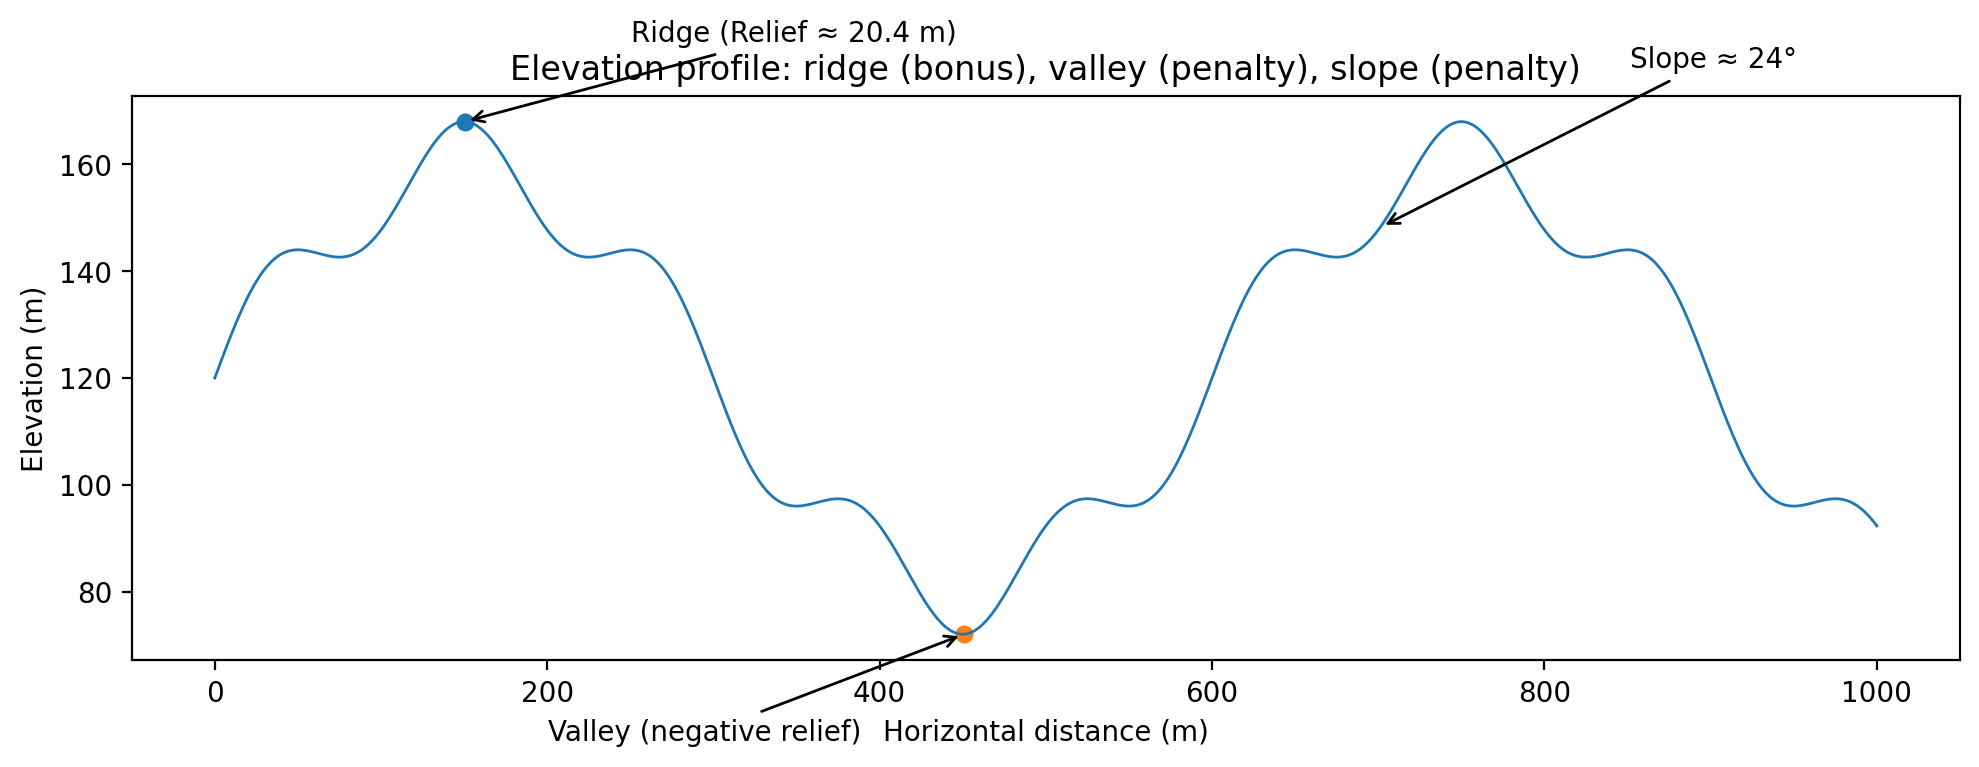

In [168]:
# Figure 3.4.1: Terrain Metrics Derived from DEM (Relief, Slope, Elevation)
import os, numpy as np, matplotlib.pyplot as plt

x = np.linspace(0, 1000, 600)
profile = 40*np.sin(2*np.pi*(x/600)) + 8*np.sin(2*np.pi*(x/120)) + 120  # synthetic terrain
# valley and ridge indices
valley_idx = np.argmin(profile)
ridge_idx  = np.argmax(profile)

# slope (deg) via central diff
dzdx = np.gradient(profile, x)
slope_deg = np.degrees(np.arctan(dzdx))

fig, ax = plt.subplots(figsize=(10,4), dpi=200)
ax.plot(x, profile, lw=1)
ax.set_xlabel("Horizontal distance (m)")
ax.set_ylabel("Elevation (m)")

# annotate relief (ridge vs median window)
win = 60
lo, hi = max(0, ridge_idx-win), min(len(profile), ridge_idx+win+1)
relief = profile[ridge_idx] - np.median(profile[lo:hi])
ax.scatter([x[ridge_idx]], [profile[ridge_idx]], s=30)
ax.annotate(f"Ridge (Relief ≈ {relief:.1f} m)", 
            xy=(x[ridge_idx], profile[ridge_idx]), xytext=(x[ridge_idx]+100, profile[ridge_idx]+15),
            arrowprops=dict(arrowstyle="->", lw=1))

ax.scatter([x[valley_idx]], [profile[valley_idx]], s=30)
ax.annotate("Valley (negative relief)", 
            xy=(x[valley_idx], profile[valley_idx]), xytext=(x[valley_idx]-250, profile[valley_idx]-20),
            arrowprops=dict(arrowstyle="->", lw=1))

# slope annotation
k = 420  # sample point for slope
ax.annotate(f"Slope ≈ {slope_deg[k]:.0f}°", 
            xy=(x[k], profile[k]), xytext=(x[k]+150, profile[k]+30),
            arrowprops=dict(arrowstyle="->", lw=1))

ax.set_title("Elevation profile: ridge (bonus), valley (penalty), slope (penalty)")
out_path = os.path.join(DATA_DIR, "fig_3_4_1_terrain_metrics.png")
plt.tight_layout()
plt.savefig(out_path, bbox_inches='tight')
print("Saved:", out_path)


Saved: /mnt/e/MTU/Thesis/Datasets/processed/fig_4_5_1_coverage_ranges.png


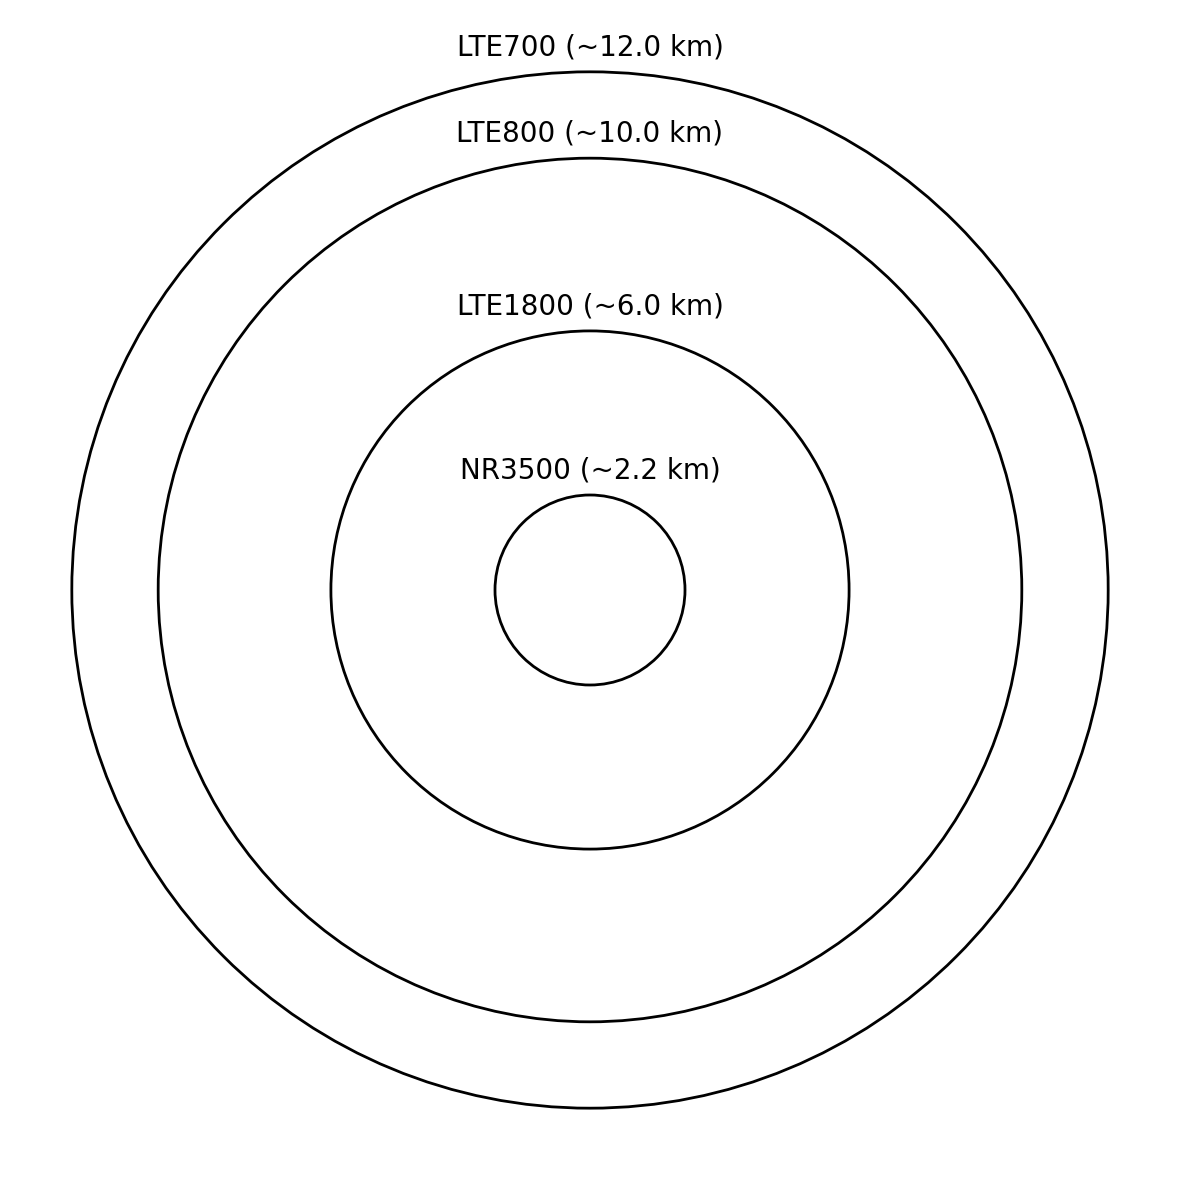

In [ ]:
# Figure 4.5.1: Comparative Coverage Ranges of 5G Frequency Bands (schematic)
import os, matplotlib.pyplot as plt, matplotlib.patches as patches


def _get_rmax(name, default):
    try:
        if name=="NR3500":
            return float(BANDS_NR[0].get("rmax_km", default))
        for b in BANDS_MACRO:
            if b["name"]==name:
                return float(b.get("rmax_km", default))
    except Exception:
        pass
    return default

r700 = _get_rmax("LTE700", 12.0)
r800 = _get_rmax("LTE800", 10.0)
r1800= _get_rmax("LTE1800",6.0)
rnr  = _get_rmax("NR3500", 2.2)

fig, ax = plt.subplots(figsize=(6,6), dpi=200)
ax.set_aspect('equal'); ax.axis('off')

# scale km → arbitrary pixels
S = 25
def ring(R, label, yshift):
    circ = patches.Circle((0,0), R*S, fill=False, lw=1)
    ax.add_patch(circ)
    ax.text(0, (R*S)+yshift, f"{label} (~{R:.1f} km)", ha='center', va='bottom', fontsize=10)

for R,label in [(r700,"LTE700"),(r800,"LTE800"),(r1800,"LTE1800"),(rnr,"NR3500")]:
    ring(R, label, 6)

ax.set_xlim(-r700*S*1.1, r700*S*1.1)
ax.set_ylim(-r700*S*1.1, r700*S*1.1)
out_path = os.path.join(DATA_DIR, "fig_4_5_1_coverage_ranges.png")
plt.tight_layout()
plt.savefig(out_path, bbox_inches='tight')
print("Saved:", out_path)


Saved: /mnt/e/MTU/Thesis/Datasets/processed/fig_4_5_2_snr_distribution.png


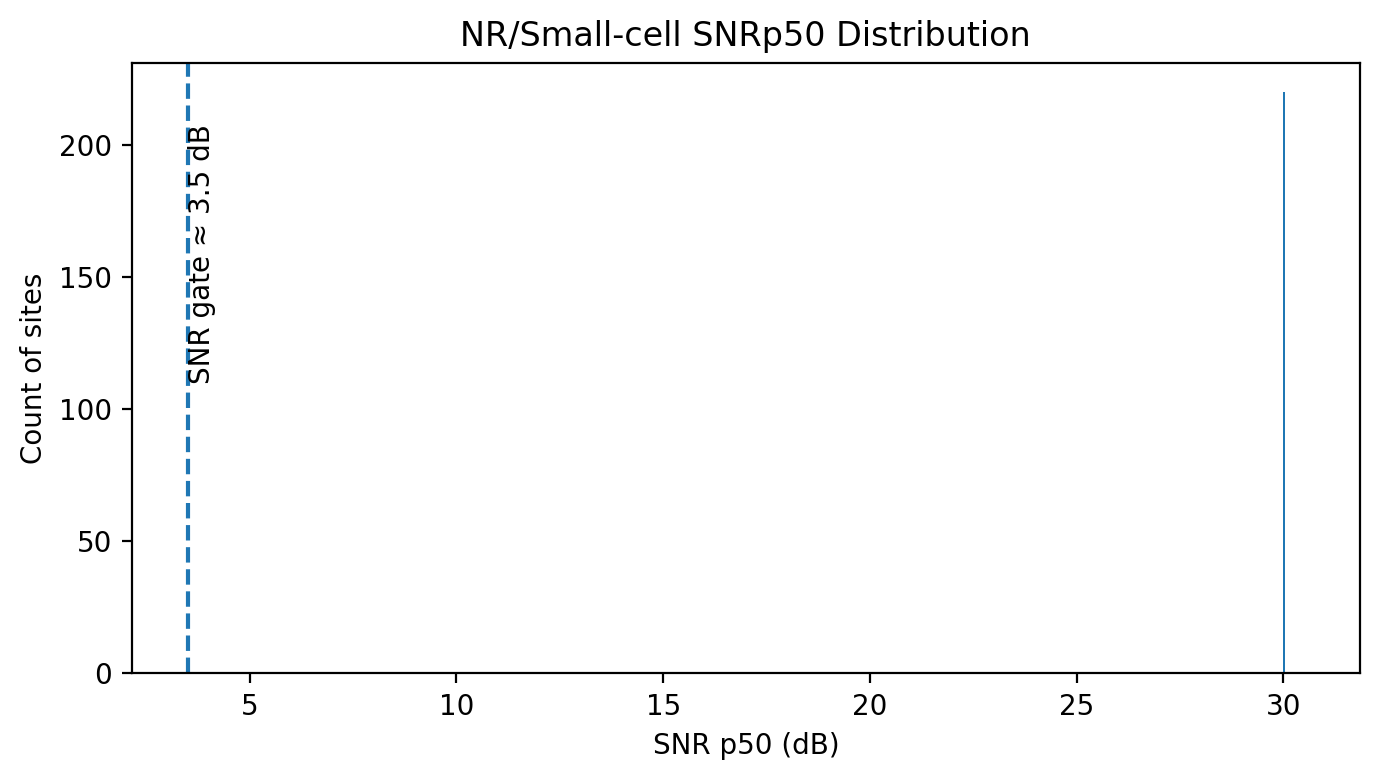

In [158]:
# Figure 4.5.2: Distribution of SNR Values across Candidate NR/Small Sites (p50)
import os, numpy as np, matplotlib.pyplot as plt, pandas as pd

# prefer 'nr_metrics' if present; else derive minimal from selected_sites rf tables if available
snr_vals = None
try:
    if 'nr_metrics' in globals() and len(nr_metrics):
        snr_vals = nr_metrics['snr_p50'].astype(float).replace([np.inf, -np.inf], np.nan).dropna().values
except Exception:
    snr_vals = None

if snr_vals is None or len(snr_vals)==0:
    # fallback: nothing to plot, make tiny placeholder
    fig, ax = plt.subplots(figsize=(6,4), dpi=200)
    ax.text(0.5, 0.5, "No NR SNR data available", ha='center', va='center')
    ax.axis('off')
else:
    fig, ax = plt.subplots(figsize=(7,4), dpi=200)
    ax.hist(snr_vals, bins=30)
    ax.set_xlabel("SNR p50 (dB)")
    ax.set_ylabel("Count of sites")
    ax.set_title("NR/Small‑cell SNRp50 Distribution")
    # vertical line at viability gate (from band)
    gate = float(BANDS_NR[0].get('snr_db', 3.5)) if 'BANDS_NR' in globals() else 3.5
    ax.axvline(gate, linestyle='--')
    ax.text(gate, ax.get_ylim()[1]*0.9, f"SNR gate ≈ {gate:.1f} dB", rotation=90, va='top')

out_path = os.path.join(DATA_DIR, "fig_4_5_2_snr_distribution.png")
plt.tight_layout()
plt.savefig(out_path, bbox_inches='tight')
print("Saved:", out_path)


Saved: /mnt/e/MTU/Thesis/Datasets/processed/fig_4_6_2a_sites_by_stage.png
Saved: /mnt/e/MTU/Thesis/Datasets/processed/fig_4_6_2b_served_bh_by_stage.png


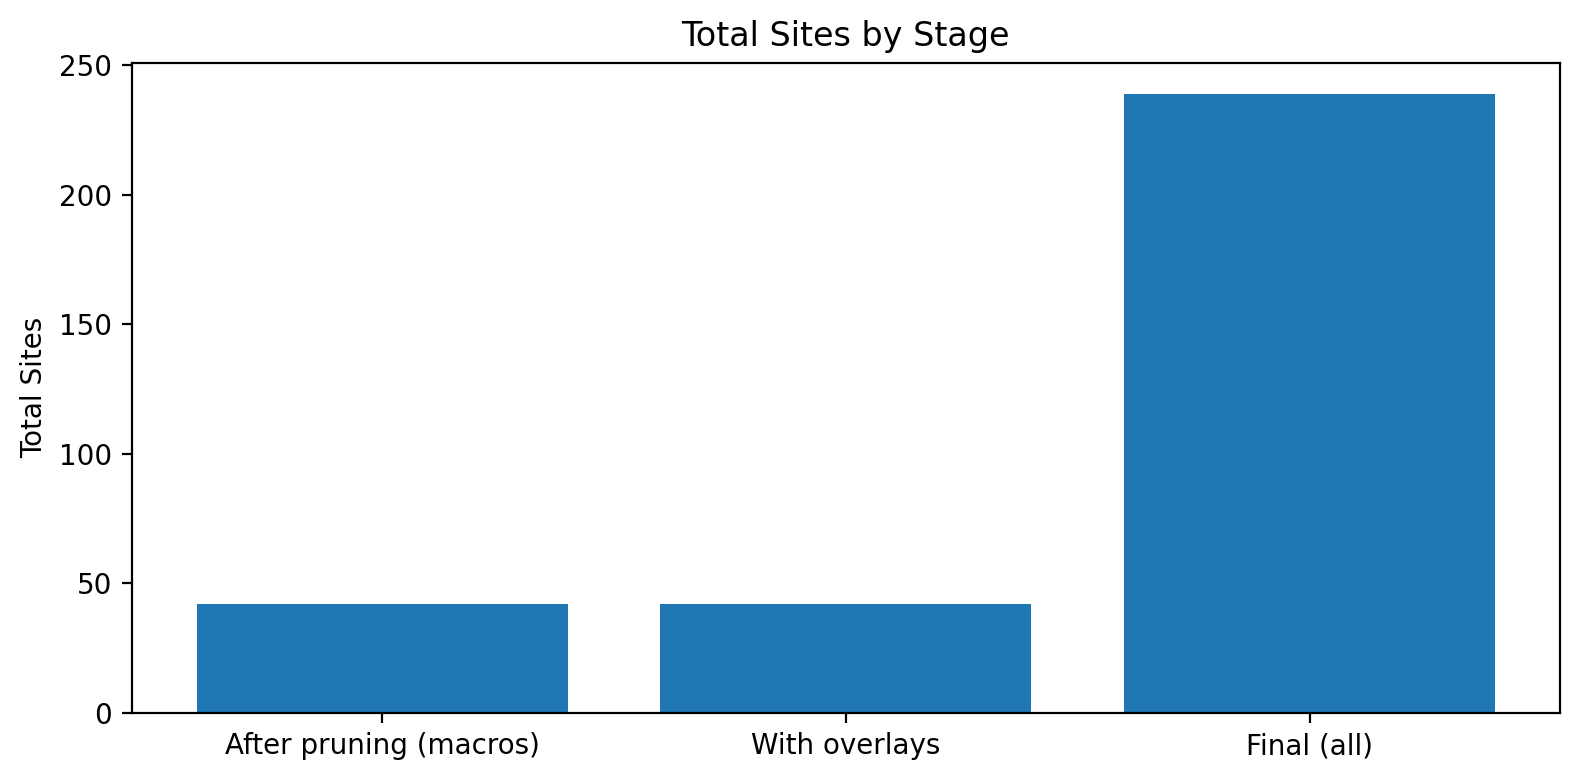

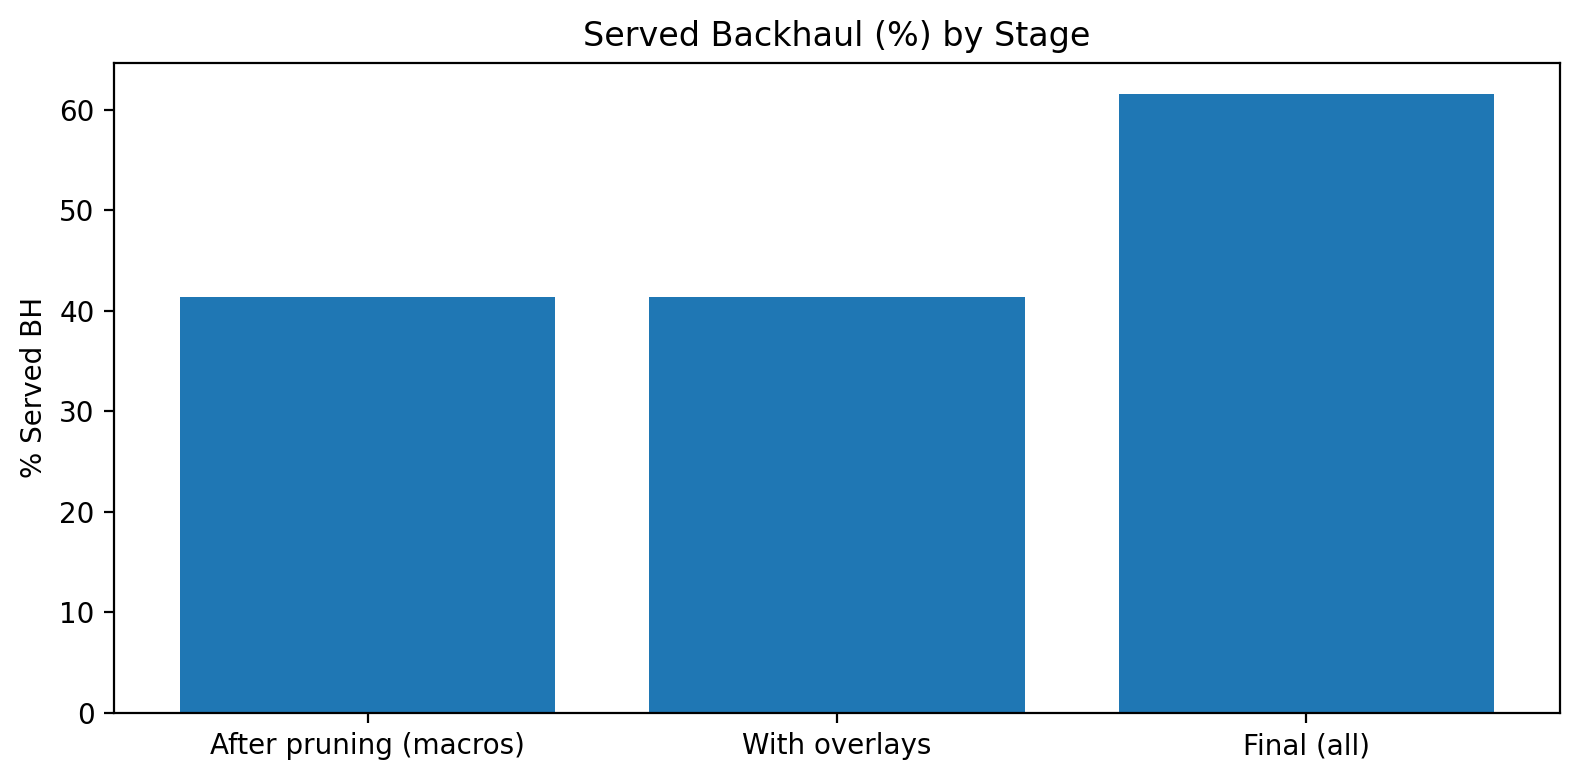

In [159]:
# Figure 4.6.2: Before vs After Optimization — Sites & Served BH
import os, pandas as pd, matplotlib.pyplot as plt

csv_path = os.path.join(DATA_DIR, "table_4_9_overlay_smallcell_effect.csv")
df = pd.read_csv(csv_path)

# Build bars: number of sites and % served
stages = df["Stage"].tolist()
n_sites = (df["Macros"].fillna(0) + df["Overlays"].fillna(0) + df["SmallCells"].fillna(0)).tolist()
pct_served = df["% Served"].str.replace("%","", regex=False).astype(float).tolist()

fig, ax = plt.subplots(figsize=(8,4), dpi=200)
ax.bar(stages, n_sites)
ax.set_ylabel("Total Sites")
ax.set_title("Total Sites by Stage")

out1 = os.path.join(DATA_DIR, "fig_4_6_2a_sites_by_stage.png")
plt.tight_layout(); plt.savefig(out1, bbox_inches='tight'); print("Saved:", out1)

fig, ax = plt.subplots(figsize=(8,4), dpi=200)
ax.bar(stages, pct_served)
ax.set_ylabel("% Served BH")
ax.set_title("Served Backhaul (%) by Stage")

out2 = os.path.join(DATA_DIR, "fig_4_6_2b_served_bh_by_stage.png")
plt.tight_layout(); plt.savefig(out2, bbox_inches='tight'); print("Saved:", out2)


Saved: /mnt/e/MTU/Thesis/Datasets/processed/fig_4_6_3_backhaul_gain.png


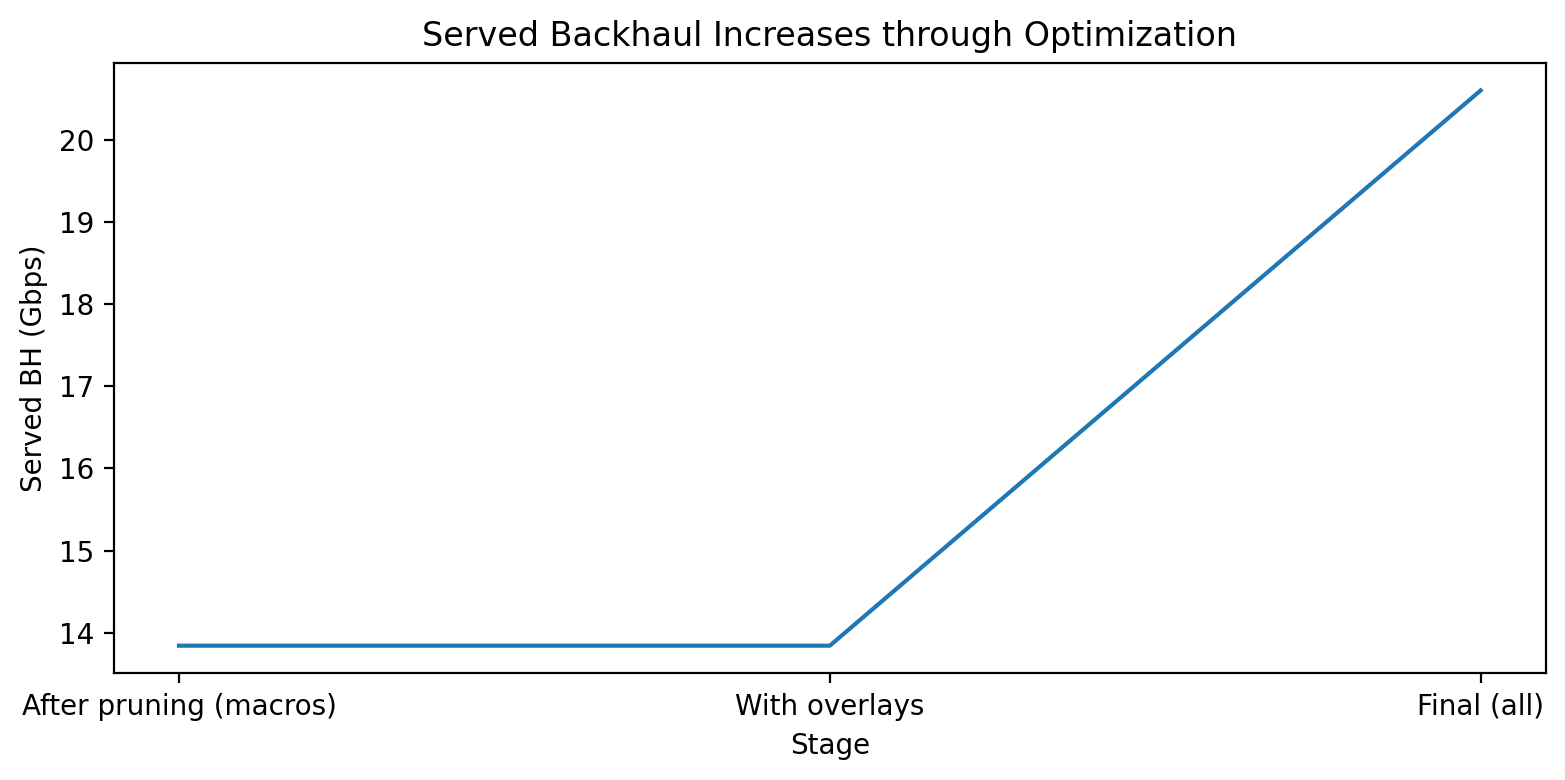

In [160]:
# Figure 4.6.3: Backhaul Served (Gbps) Gain across Stages
import os, pandas as pd, matplotlib.pyplot as plt

csv_path = os.path.join(DATA_DIR, "table_4_9_overlay_smallcell_effect.csv")
df = pd.read_csv(csv_path)

fig, ax = plt.subplots(figsize=(8,4), dpi=200)
ax.plot(df["Stage"], df["Served BH (Gbps)"])
ax.set_xlabel("Stage")
ax.set_ylabel("Served BH (Gbps)")
ax.set_title("Served Backhaul Increases through Optimization")

out_path = os.path.join(DATA_DIR, "fig_4_6_3_backhaul_gain.png")
plt.tight_layout(); plt.savefig(out_path, bbox_inches='tight')
print("Saved:", out_path)


Saved: /mnt/e/MTU/Thesis/Datasets/processed/fig_4_3_1_cluster_stats.png


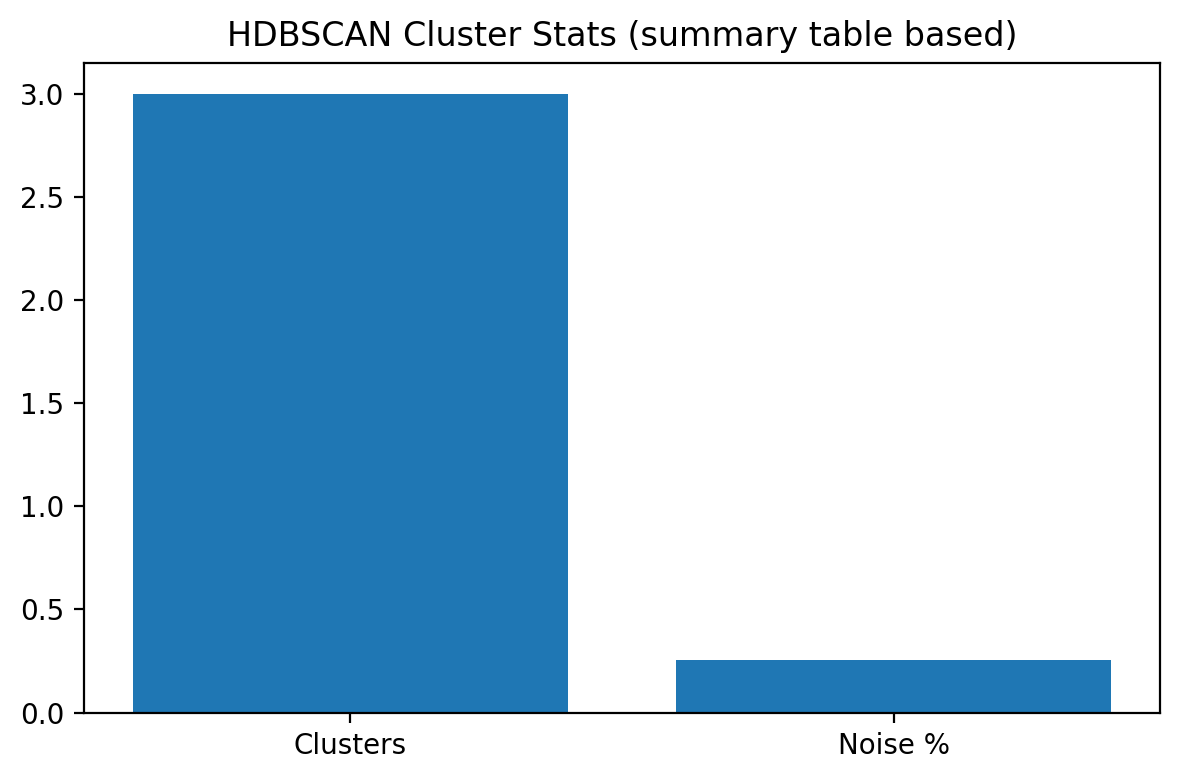

In [ ]:
# Figure 4.3.1: DBSCAN vs HDBSCAN — Cluster Count & Noise Share (from Table 4.3)

import os, pandas as pd, matplotlib.pyplot as plt

csv_path = os.path.join(DATA_DIR, "table_4_3_cluster_summary.csv")
if os.path.exists(csv_path):
    t43 = pd.read_csv(csv_path)
    # Count non-noise clusters and size
    is_noise = t43["Cluster ID"].astype(str).str.lower().eq("noise")
    n_clusters = (~is_noise).sum()
    noise_pts = t43.loc[is_noise, "Size (points)"].sum() if is_noise.any() else 0
    total_pts = t43["Size (points)"].sum()
    noise_pct = 100.0 * noise_pts / max(1, total_pts)

    fig, ax = plt.subplots(figsize=(6,4), dpi=200)
    ax.bar(["Clusters", "Noise %"], [n_clusters, noise_pct])
    ax.set_title("HDBSCAN Cluster Stats (summary table based)")
    out_path = os.path.join(DATA_DIR, "fig_4_3_1_cluster_stats.png")
    plt.tight_layout(); plt.savefig(out_path, bbox_inches='tight')
    print("Saved:", out_path)
else:
    print("Skip: table_4_3_cluster_summary.csv not found.")
